# Resident Risk Prediction Pipeline
## Lighthouse Sanctuary — ML Pipeline (CRISP-DM Framework)

This notebook builds a complete **end-to-end machine learning pipeline** that predicts
the **current risk level** of a resident — giving social workers an early warning system
to identify girls who are struggling, progressing, or ready for reintegration.

The model uses **binary classification**: residents are grouped into two clinically
meaningful categories — **Standard Risk** (stable/monitoring) and **Elevated Risk**
(intensive support needed). This framing is more reliable than four classes when working
with a small dataset of 60 residents, where rare High/Critical cases cannot be reliably
separated by a model alone.

A **rule-based safety layer** runs alongside the model: hard clinical thresholds
(e.g., any self-harm event) can independently flag Elevated Risk regardless of the
model's output. Both signals are shown together so staff see the full picture.

It follows the **CRISP-DM** framework (Cross-Industry Standard Process for Data Mining),
the industry-standard approach for turning raw data into reliable predictions.

---

### The 6 CRISP-DM Phases Covered Here:

| Phase | What We Do |
|---|---|
| **1. Business Understanding** | Define the problem, success criteria, and what risk means in the real world |
| **2. Data Understanding** | Explore the data — distributions, patterns, data quality issues |
| **3. Data Preparation** | Join tables, engineer features, clean, encode, and split the data |
| **4. Modeling** | Train 5 ensemble models with SMOTE oversampling for class balance |
| **5. Evaluation** | Tune, compare, final-test, and apply the rule-based safety layer |
| **6. Deployment** | Save the model and build a reusable `predict_risk()` function |

---

### Our Goal:
**Predict `current_risk_level`** — mapped to a binary outcome:

| Binary Label | Original Risk Levels | Meaning in the Field |
|---|---|---|
| **Standard Risk (0)** | Low + Medium | Stable or monitoring. Standard care pathway. |
| **Elevated Risk (1)** | High + Critical | Intensive intervention or crisis support needed. |

---

### Important — What This Model Does NOT Do:
This model supports human decision-making — it does not replace it. A predicted risk
level is an input to a social worker's judgment, not a final verdict. The safety rule
layer adds an additional hard-coded clinical screen for the most serious warning signs.

In [20]:
# =============================================================================
# PIPELINE CONFIGURATION
# To run this pipeline on a different dataset, only change the values in this
# cell. Everything below adapts automatically.
# =============================================================================

# Paths to CSV files (relative to this notebook's location)
RESIDENTS_PATH   = "lighthouse_csv_v7/residents.csv"
INCIDENTS_PATH   = "lighthouse_csv_v7/incident_reports.csv"
PROCESS_PATH     = "lighthouse_csv_v7/process_recordings.csv"
VISITATIONS_PATH = "lighthouse_csv_v7/home_visitations.csv"

# The column we want to predict
TARGET_COL = "current_risk_level"

# Fraction of data held back for the final honest test (0.2 = 20%)
TEST_SIZE = 0.2

# Random seed — ensures identical results every run
RANDOM_STATE = 27

# Path to save the trained model artifact
MODEL_SAVE_PATH = "models/resident_risk_model.joblib"

# =============================================================================
# BINARY TARGET ENCODING
# Low + Medium  →  0  ("Standard Risk")
# High + Critical  →  1  ("Elevated Risk")
#
# WHY BINARY? With only 60 residents there is just 1 Critical and 5 High cases.
# A 4-class model cannot reliably learn those rare classes from such limited data
# (0% recall on Critical in testing). Merging into a clinically meaningful binary
# — "needs elevated support" vs. "standard care pathway" — gives the model a
# real chance to correctly flag the residents who need the most attention.
# As the dataset grows, the model can be extended back to 4 classes.
# =============================================================================
ORDINAL_MAP         = {"Low": 0, "Medium": 0, "High": 1, "Critical": 1}
ORDINAL_MAP_INVERSE = {0: "Standard Risk", 1: "Elevated Risk"}

# =============================================================================
# SAFETY RULE THRESHOLDS — Hard clinical rules that independently flag risk.
# These act as a safety net: even if the ML model predicts Standard Risk,
# certain clinical signals are serious enough to override and flag Elevated Risk.
#
# Format: rule_name → (feature_column, operator, threshold)
# Rules applied (any one TRUE → flag as Elevated Risk):
#   1. Any self-harm event on record
#   2. 50%+ of incidents are High severity
#   3. Two or more runaway attempts
#   4. 50%+ of home visits noted safety concerns
#   5. 50%+ of home visits had Unfavorable outcomes
# =============================================================================
SAFETY_RULES = {
    "num_self_harm_gt_0":          ("num_self_harm",             ">",  0),
    "pct_high_severity_gte_50pct": ("pct_high_severity",         ">=", 0.5),
    "num_runaway_gte_2":           ("num_runaway_attempts",       ">=", 2),
    "pct_safety_concerns_gte_50":  ("pct_safety_concerns_noted", ">=", 0.5),
    "pct_unfavorable_gte_50":      ("pct_unfavorable_outcome",   ">=", 0.5),
}

# =============================================================================
# LEAKAGE AND EXCLUSION COLUMNS
# =============================================================================

# LEAKAGE COLUMNS — These are the target itself or directly derived from it.
# Using them would make the model look perfect in testing but fail in production.
LEAKAGE_COLS = [
    "current_risk_level",       # This IS our target — cannot be a feature
    "notes_restricted",         # Free-text that likely contains direct risk descriptions
    "date_closed",              # Only populated when a case is closed (outcome info)
    "case_status",              # Active/Closed/Transferred — reflects the outcome of the case
]

# NON-PREDICTIVE COLUMNS — Identifiers, names, redundant dates, or zero-variance fields
DROP_COLS = [
    "resident_id",              # Row identifier — no predictive value
    "case_control_no",          # Internal case number — identifier
    "internal_code",            # Anonymized ID — identifier
    "safehouse_id",             # We will pull safehouse context separately if needed
    "sex",                      # All residents are Female — zero variance
    "age_upon_admission",       # Inaccurate string field — we derive age from raw dates
    "present_age",              # Inaccurate string field — not used
    "length_of_stay",           # Inaccurate string field — we derive days_in_care from dates
    "referring_agency_person",  # High-cardinality free-text name
    "assigned_social_worker",   # High-cardinality name field
    "initial_case_assessment",  # Free-text — complex NLP; not used in this version
    "date_colb_registered",     # Administrative document date — low signal
    "date_colb_obtained",       # Administrative document date — low signal
    "date_case_study_prepared", # Administrative date — low signal
    "date_enrolled",            # Duplicate of date_of_admission
    "created_at",               # Record creation timestamp — not meaningful for risk
    "place_of_birth",           # High-cardinality location — low signal
    "religion",                 # Low expected signal for risk prediction
]

print("Pipeline configuration loaded.")
print(f"  Target variable : {TARGET_COL}  (binary)")
print(f"  Binary map      : {ORDINAL_MAP}")
print(f"  Labels          : {ORDINAL_MAP_INVERSE}")
print(f"  Test size       : {TEST_SIZE:.0%}")
print(f"  Random state    : {RANDOM_STATE}")
print(f"  Model save path : {MODEL_SAVE_PATH}")
print(f"  Safety rules    : {len(SAFETY_RULES)} rules defined")

Pipeline configuration loaded.
  Target variable : current_risk_level  (binary)
  Binary map      : {'Low': 0, 'Medium': 0, 'High': 1, 'Critical': 1}
  Labels          : {0: 'Standard Risk', 1: 'Elevated Risk'}
  Test size       : 20%
  Random state    : 27
  Model save path : models/resident_risk_model.joblib
  Safety rules    : 5 rules defined


# Phase 1: Business Understanding

## Who Are We Building This For?

**Lighthouse Sanctuary** is a US-based nonprofit (501(c)(3)) that operates safe homes
for girls who are survivors of sexual abuse and trafficking in the Philippines. A new
organization modeled after Lighthouse Sanctuary is being built from scratch. This ML
pipeline is one piece of the technology stack powering that new organization.

---

## The Problem

With **limited staff managing multiple safehouses**, social workers cannot always give
equal attention to every resident. Key questions they face every day include:

- Which girls are **progressing** and getting closer to safe reintegration?
- Which girls are **struggling** and need more intensive support right now?
- Which **interventions are actually working** — and which are not?
- When might a resident be **at risk of regression** if support is reduced?

Currently, these questions are answered primarily through formal case reviews, which happen
on a fixed schedule. The problem is that risk can change between reviews, and staff may not
catch a deteriorating situation until it becomes a crisis.

---

## Our ML Solution

We build a **binary risk classification model** that predicts whether a resident needs
standard or elevated care:

| Binary Label | Original Risk Levels | Meaning in the Field |
|---|---|---|
| **Standard Risk** | Low + Medium | Stable or monitoring. Progressing on the standard care pathway. Some concerns may exist but no immediate crisis. |
| **Elevated Risk** | High + Critical | Significant challenges or immediate risk. Intensive or crisis-level support is needed now. |

### Why Binary Instead of Four Classes?

The original dataset has only **60 residents**, with just 1 Critical and 5 High cases.
A 4-class model statistically cannot learn to recognize Critical cases from a single example
— cross-validation confirmed 0% recall on Critical. Merging High + Critical into one
"Elevated Risk" class gives the model enough positive examples (~10%) to actually learn
the boundary that matters most to staff.

The model uses features from four data sources:
- **Case records** (`residents` table): trauma history, family situation, referral source
- **Counseling sessions** (`process_recordings`): emotional trends, session frequency, progress notes
- **Home visits** (`home_visitations`): family cooperation, safety concerns, visit outcomes
- **Incident reports** (`incident_reports`): incident frequency, severity, types

### Safety Rule Layer

Because the ML model may still miss edge cases with a small dataset, a **rule-based safety layer**
runs alongside every prediction. Five hard clinical thresholds — such as any self-harm event or
50%+ high-severity incidents — can independently flag Elevated Risk, regardless of the model output.
Staff see both signals together.

---

## Success Criteria

| Metric | What It Measures |
|---|---|
| **Balanced Accuracy** | Accuracy adjusted for class imbalance — primary metric |
| **Recall (Elevated Risk)** | What fraction of truly Elevated residents does the model catch? (minimizing misses) |
| **Precision (Elevated Risk)** | Of residents flagged as Elevated, how many actually are? |
| **Binary F1 (Elevated)** | Combined precision + recall for the Elevated class |

**Baseline to beat:** A "dumb" model that always predicts Standard Risk achieves ~90%
raw accuracy but 50% balanced accuracy (misses every Elevated case). Our goal is to
meaningfully outperform this baseline, especially on recall for the Elevated class.

---

## Key Constraints and Ethical Notes

1. **Class imbalance**: With only 60 residents, roughly 6 are Elevated Risk. SMOTE
   oversampling is applied to the training set to artificially balance the classes and
   help the model learn the minority class signal.

2. **Small dataset**: 60 rows is a very small training set for machine learning. Results
   should be interpreted with appropriate humility. As the organization grows and collects
   more data, the model will improve.

3. **Model as a tool, not a verdict**: Risk predictions should always be reviewed by a
   trained social worker. The model helps prioritize attention — it does not replace judgment.

# Phase 2: Data Understanding

Before training any model, we explore the data to understand:
- What tables exist, how many rows each has, and which residents are covered
- How the target variable (`current_risk_level`) is distributed across classes
- Patterns in trauma flags, incident history, and session data by risk level
- Missing values and data quality issues that will affect preparation

Think of this as reading the medical chart before making a diagnosis — the more you
understand the data, the better the model and its recommendations will be.

In [21]:
# =============================================================================
# PHASE 2, STEP 1: Import libraries and load all four datasets
# =============================================================================

# Suppress minor warnings so the output stays readable
import warnings
warnings.filterwarnings("ignore")

# numpy — math and array operations (the backbone of numerical Python)
import numpy as np

# pandas — load and manipulate tabular data (like a spreadsheet in Python)
import pandas as pd

# matplotlib and seaborn — for creating charts and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent, clean visual style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"]     = 100

# --- Load the four CSVs ---
# Each CSV maps to a database table. We load them separately and will join
# them in Phase 3 after aggregating the supporting tables per resident.
df_residents   = pd.read_csv(RESIDENTS_PATH)
df_incidents   = pd.read_csv(INCIDENTS_PATH)
df_process     = pd.read_csv(PROCESS_PATH)
df_visitations = pd.read_csv(VISITATIONS_PATH)

print("All datasets loaded successfully!")
print()
print(f"{'Table':<30} {'Rows':>6}  {'Columns':>8}  {'Unique Residents':>18}")
print("-" * 70)
print(f"{'residents':<30} {df_residents.shape[0]:>6}  {df_residents.shape[1]:>8}  {'(primary table)':>18}")
print(f"{'incident_reports':<30} {df_incidents.shape[0]:>6}  {df_incidents.shape[1]:>8}  {df_incidents['resident_id'].nunique():>18}")
print(f"{'process_recordings':<30} {df_process.shape[0]:>6}  {df_process.shape[1]:>8}  {df_process['resident_id'].nunique():>18}")
print(f"{'home_visitations':<30} {df_visitations.shape[0]:>6}  {df_visitations.shape[1]:>8}  {df_visitations['resident_id'].nunique():>18}")
print()
print(f"Total residents in primary table: {len(df_residents)}")
print(f"NOTE: {len(df_residents) - df_incidents['resident_id'].nunique()} residents have zero incident records.")
print(f"NOTE: {len(df_residents) - df_visitations['resident_id'].nunique()} residents have zero home visitation records.")

All datasets loaded successfully!

Table                            Rows   Columns    Unique Residents
----------------------------------------------------------------------
residents                          60        49     (primary table)
incident_reports                  100        12                  44
process_recordings               2819        15                  60
home_visitations                 1337        14                  58

Total residents in primary table: 60
NOTE: 16 residents have zero incident records.
NOTE: 2 residents have zero home visitation records.


=== Target Variable: current_risk_level (Original 4-Class Distribution) ===

Risk Level    Count   Percent
--------------------------------
Low              34    56.7%  ############################
Medium           20    33.3%  ################
High              5     8.3%  ####
Critical          1     1.7%  

Total residents: 60

Class Imbalance Warning:
   Low      = 34 (57%) — dominant class
   Medium   = 20 (33%)
   High     = 5 (8%)
   Critical = 1 (2%) — only 1 example!

=== After Binary Merge (what the model learns) ===
   Standard Risk (Low+Medium)   = 54 residents (90%)
   Elevated Risk  (High+Critical) = 6  residents (10%)

Strategy: SMOTE oversampling will balance the Elevated class in training.
Balanced accuracy will be our primary evaluation metric.


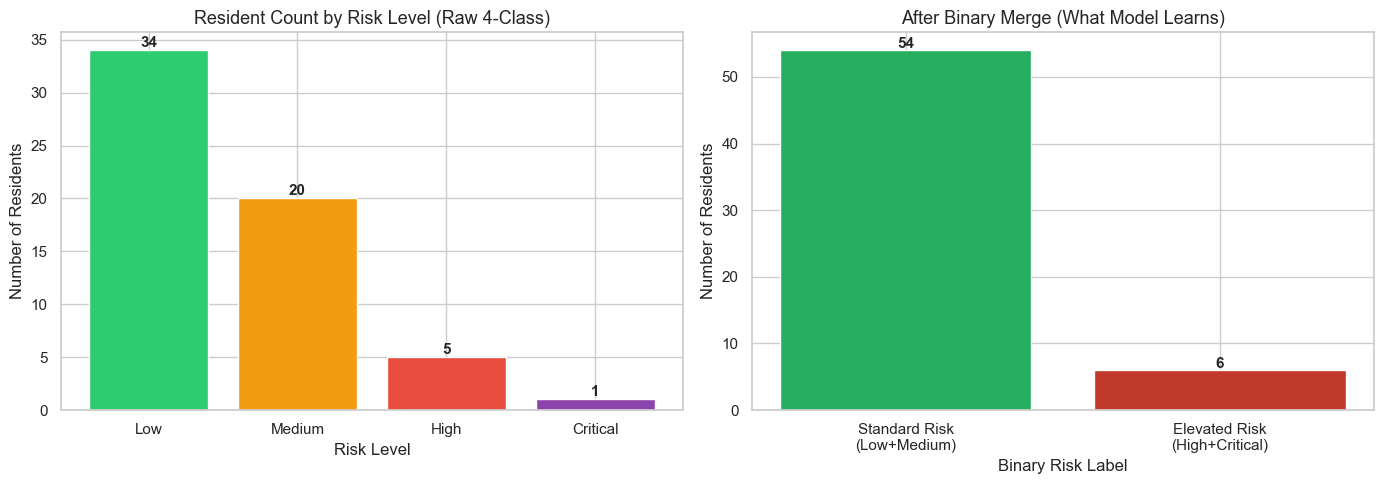

Risk level change summary (original 4-class):
  No change (stable)       : 32 residents (53%)
  Improved (risk decreased): 28 residents (47%)
  Worsened (risk increased): 0 residents (0%)


In [22]:
# =============================================================================
# PHASE 2, STEP 2: Explore the target variable distribution
#
# The target variable is 'current_risk_level'. The raw data has four categories:
#   Low, Medium, High, Critical
#
# In Phase 3, we MERGE these into two binary classes:
#   Standard Risk (0)  =  Low  + Medium
#   Elevated Risk  (1)  =  High + Critical
#
# This section shows the original 4-class distribution to understand the data.
# The binary merge note at the bottom shows what the model will actually learn.
#
# IMPORTANT: Class imbalance!
# If one class has far more examples than others, the model may learn to
# always predict the common class and ignore rare ones. We address this with
# SMOTE oversampling in Phase 4.
# =============================================================================

risk_order  = ["Low", "Medium", "High", "Critical"]
risk_counts = df_residents[TARGET_COL].value_counts().reindex(risk_order)
risk_pct    = risk_counts / len(df_residents) * 100

print("=== Target Variable: current_risk_level (Original 4-Class Distribution) ===")
print()
print(f"{'Risk Level':<12} {'Count':>6}  {'Percent':>8}")
print("-" * 32)
for level in risk_order:
    bar = "#" * int(risk_pct[level] / 2)
    print(f"{level:<12} {risk_counts[level]:>6}  {risk_pct[level]:>6.1f}%  {bar}")

print()
print(f"Total residents: {len(df_residents)}")
print()
print("Class Imbalance Warning:")
print(f"   Low      = {risk_counts['Low']} ({risk_pct['Low']:.0f}%) — dominant class")
print(f"   Medium   = {risk_counts['Medium']} ({risk_pct['Medium']:.0f}%)")
print(f"   High     = {risk_counts['High']} ({risk_pct['High']:.0f}%)")
print(f"   Critical = {risk_counts['Critical']} ({risk_pct['Critical']:.0f}%) — only 1 example!")

# --- Binary merge preview ---
standard_count  = risk_counts["Low"]  + risk_counts["Medium"]
elevated_count  = risk_counts["High"] + risk_counts["Critical"]
standard_pct    = standard_count / len(df_residents) * 100
elevated_pct    = elevated_count / len(df_residents) * 100

print()
print("=== After Binary Merge (what the model learns) ===")
print(f"   Standard Risk (Low+Medium)   = {standard_count} residents ({standard_pct:.0f}%)")
print(f"   Elevated Risk  (High+Critical) = {elevated_count}  residents ({elevated_pct:.0f}%)")
print()
print("Strategy: SMOTE oversampling will balance the Elevated class in training.")
print("Balanced accuracy will be our primary evaluation metric.")

# --- Chart: Bar chart of risk level distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 4-class counts
axes[0].bar(risk_order, risk_counts.values, color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"])
axes[0].set_title("Resident Count by Risk Level (Raw 4-Class)", fontsize=13)
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Number of Residents")
for i, (level, count) in enumerate(zip(risk_order, risk_counts.values)):
    axes[0].text(i, count + 0.3, str(count), ha="center", fontsize=11, fontweight="bold")

# Right: binary merge view
binary_labels  = ["Standard Risk\n(Low+Medium)", "Elevated Risk\n(High+Critical)"]
binary_counts  = [standard_count, elevated_count]
binary_colors  = ["#27ae60", "#c0392b"]
axes[1].bar(binary_labels, binary_counts, color=binary_colors)
axes[1].set_title("After Binary Merge (What Model Learns)", fontsize=13)
axes[1].set_xlabel("Binary Risk Label")
axes[1].set_ylabel("Number of Residents")
for i, count in enumerate(binary_counts):
    axes[1].text(i, count + 0.3, str(count), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Summary of risk changes (original 4-class crosstab for reference)
risk_cross = pd.crosstab(
    df_residents["initial_risk_level"].reindex(df_residents.index),
    df_residents["current_risk_level"],
    rownames=["Initial Risk Level"],
    colnames=["Current Risk Level"]
).reindex(index=risk_order, columns=risk_order, fill_value=0)

no_change = sum(risk_cross.iloc[i, i] for i in range(len(risk_order)))
improved  = sum(risk_cross.iloc[i, j] for i in range(len(risk_order)) for j in range(i))
worsened  = sum(risk_cross.iloc[i, j] for i in range(len(risk_order)) for j in range(i+1, len(risk_order)))
print(f"Risk level change summary (original 4-class):")
print(f"  No change (stable)       : {no_change} residents ({no_change/len(df_residents)*100:.0f}%)")
print(f"  Improved (risk decreased): {improved} residents ({improved/len(df_residents)*100:.0f}%)")
print(f"  Worsened (risk increased): {worsened} residents ({worsened/len(df_residents)*100:.0f}%)")

=== Trauma/Vulnerability Flags by Risk Level (% of residents in each group) ===

                          Low  Medium  High  Critical
sub_cat_orphaned          8.8    35.0   0.0       0.0
sub_cat_trafficked       17.6    20.0  20.0       0.0
sub_cat_child_labor      14.7    10.0  40.0     100.0
sub_cat_physical_abuse   14.7    10.0   0.0       0.0
sub_cat_sexual_abuse     17.6    35.0  40.0       0.0
sub_cat_osaec            14.7    10.0  20.0       0.0
sub_cat_cicl             17.6    10.0  20.0       0.0
sub_cat_at_risk          23.5    20.0  20.0     100.0
sub_cat_street_child     14.7    10.0  20.0     100.0
sub_cat_child_with_hiv    2.9    10.0   0.0       0.0
is_pwd                    8.8     0.0   0.0       0.0
has_special_needs        11.8     5.0  20.0       0.0
family_is_4ps            41.2    20.0  20.0       0.0
family_solo_parent       35.3    50.0  40.0       0.0
family_indigenous        14.7    25.0   0.0       0.0
family_parent_pwd         5.9     5.0   0.0       0.0
f

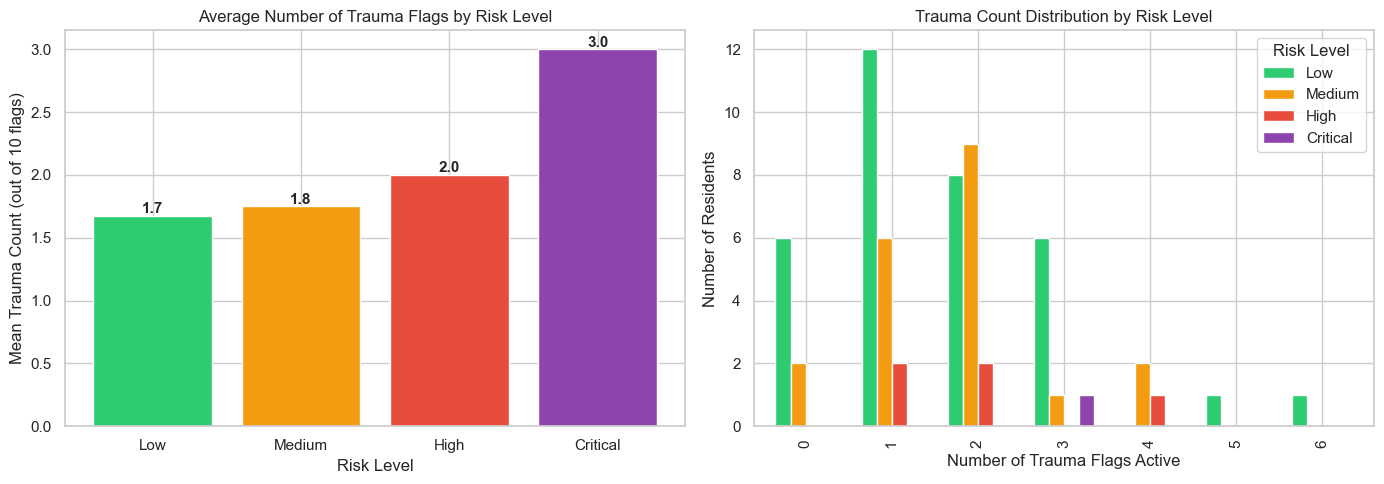

Key Insight: Higher-risk residents tend to have more trauma flags.
  Mean trauma count — Low=1.7, Medium=1.8, High=2.0, Critical=3.0


In [23]:
# =============================================================================
# PHASE 2, STEP 3: Explore trauma flags and family vulnerability by risk level
#
# The residents table contains 9 boolean "sub_cat_*" flags that indicate
# specific types of trauma a resident has experienced. We expect higher-risk
# residents to have more of these flags set to True.
#
# A "boolean flag" is simply a True/False column — True means the condition applies.
# =============================================================================

sub_cat_cols = [
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "sub_cat_cicl",
    "sub_cat_at_risk",
    "sub_cat_street_child",
    "sub_cat_child_with_hiv",
    "is_pwd",
    "has_special_needs",
]

family_flag_cols = [
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
]

# --- Calculate percent of residents with each flag, grouped by risk level ---
print("=== Trauma/Vulnerability Flags by Risk Level (% of residents in each group) ===")
print()

flag_rates = {}
for level in risk_order:
    subset = df_residents[df_residents[TARGET_COL] == level]
    if len(subset) == 0:
        continue
    rates = {}
    for col in sub_cat_cols + family_flag_cols:
        if col in df_residents.columns:
            rates[col] = subset[col].mean() * 100
    flag_rates[level] = rates

flag_df = pd.DataFrame(flag_rates).round(1)

print(flag_df.to_string())
print()

# --- Bar chart: trauma count distribution by risk level ---
# "Trauma count" = how many sub_cat_* flags are True for a given resident
available_sub_cats = [c for c in sub_cat_cols if c in df_residents.columns]
df_residents["trauma_count"] = df_residents[available_sub_cats].sum(axis=1)

trauma_by_risk = df_residents.groupby(TARGET_COL)["trauma_count"].agg(["mean", "median"]).reindex(risk_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean trauma count per risk level
axes[0].bar(risk_order, trauma_by_risk["mean"],
            color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"])
axes[0].set_title("Average Number of Trauma Flags by Risk Level", fontsize=12)
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Mean Trauma Count (out of 10 flags)")
for i, val in enumerate(trauma_by_risk["mean"]):
    axes[0].text(i, val + 0.02, f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

# Right: distribution of trauma count across all residents
df_residents.groupby([TARGET_COL, "trauma_count"]).size().unstack(fill_value=0).reindex(risk_order).T.plot(
    kind="bar", ax=axes[1],
    color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"],
    width=0.7
)
axes[1].set_title("Trauma Count Distribution by Risk Level", fontsize=12)
axes[1].set_xlabel("Number of Trauma Flags Active")
axes[1].set_ylabel("Number of Residents")
axes[1].legend(title="Risk Level")

plt.tight_layout()
plt.show()

print("Key Insight: Higher-risk residents tend to have more trauma flags.")
print(f"  Mean trauma count — Low={trauma_by_risk['mean']['Low']:.1f}, Medium={trauma_by_risk['mean']['Medium']:.1f}, High={trauma_by_risk['mean']['High']:.1f}, Critical={trauma_by_risk['mean']['Critical']:.1f}")

=== Supporting Table Signals by Risk Level ===

                   incident_count      session_count      concerns_flagged_rate visit_count       safety_concern_rate
                             mean  max          mean  max                  mean        mean   max                mean
current_risk_level                                                                                                   
Low                      1.294118  4.0     41.441176   89              0.248469   21.529412  64.0            0.270507
Medium                   1.750000  5.0     44.600000  110              0.250494   19.300000  35.0            0.231668
High                     3.800000  5.0     88.800000  118              0.253376   38.200000  64.0            0.282784
Critical                 2.000000  2.0     74.000000   74              0.243243   28.000000  28.0            0.357143



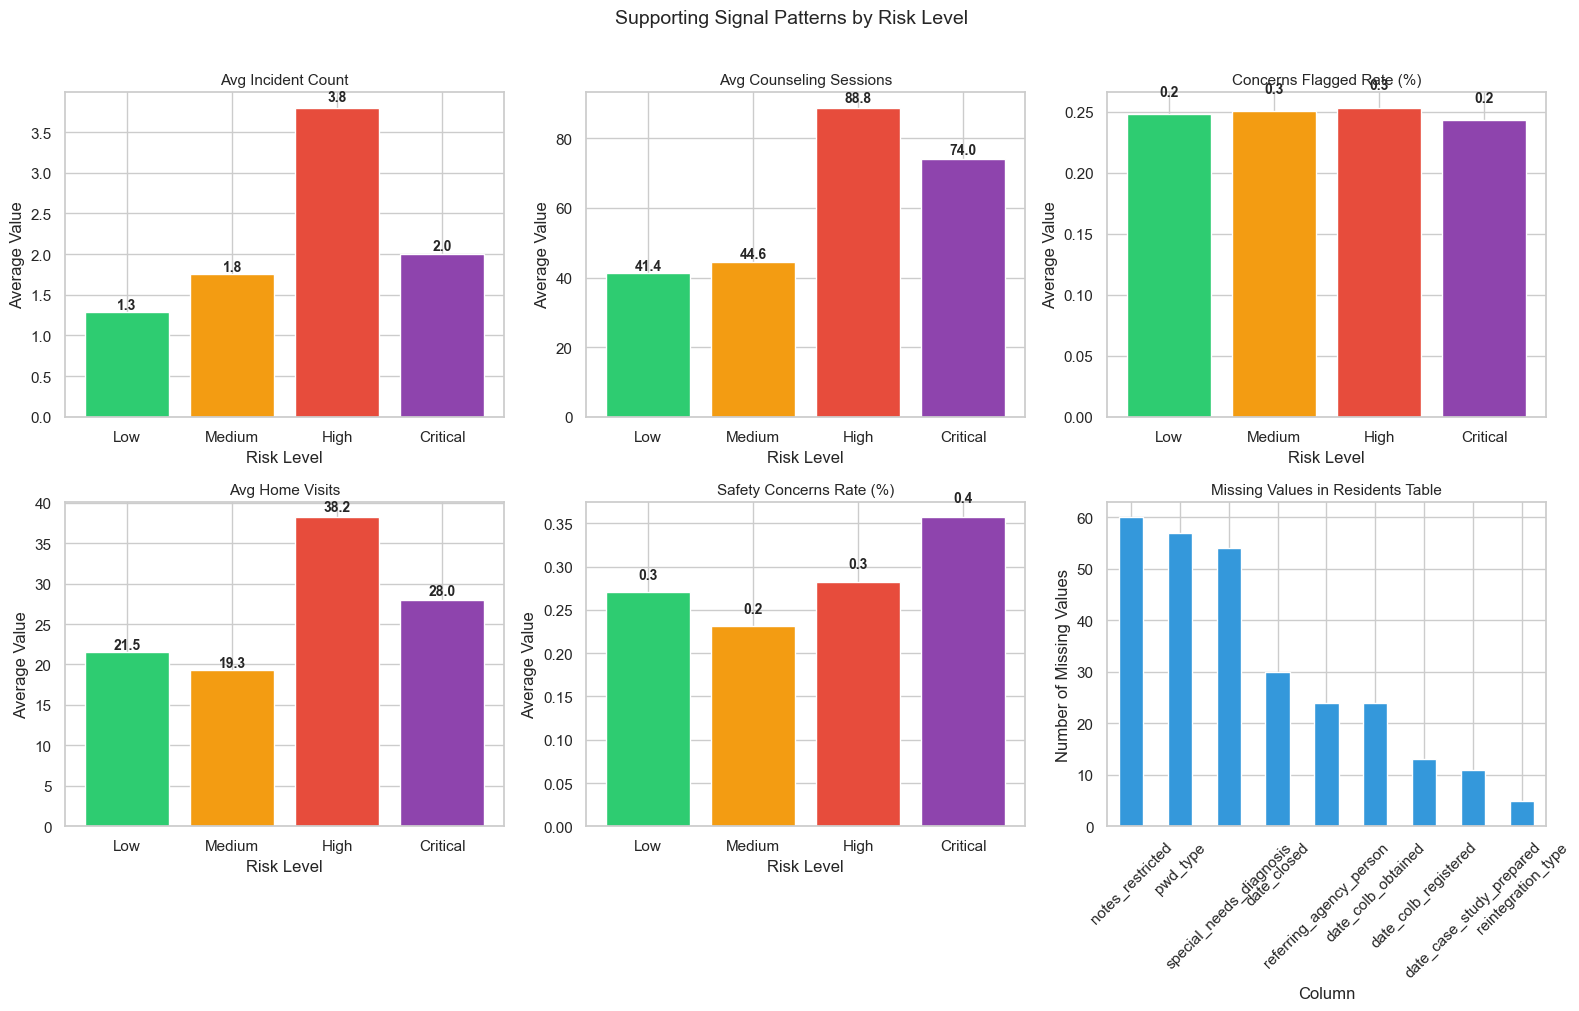

Key Insights:
  - Higher-risk residents tend to have more incidents (especially self-harm/runaway)
  - Safety concerns during home visits correlate with higher risk
  - Concerns flagged in counseling sessions increase with risk level


In [24]:
# =============================================================================
# PHASE 2, STEP 4: Explore incident and counseling session patterns by risk level
#
# We look at how the supporting tables relate to risk level at the aggregate level.
# For example: do higher-risk residents have more incidents? More concerns flagged in sessions?
# =============================================================================

# --- Merge basic incident counts into residents for EDA ---
incident_counts = df_incidents.groupby("resident_id").size().rename("incident_count")
session_counts  = df_process.groupby("resident_id").size().rename("session_count")
concerns_rate   = df_process.groupby("resident_id")["concerns_flagged"].mean().rename("concerns_flagged_rate")
visit_counts    = df_visitations.groupby("resident_id").size().rename("visit_count")
safety_rate     = df_visitations.groupby("resident_id")["safety_concerns_noted"].mean().rename("safety_concern_rate")

df_eda = df_residents[["resident_id", TARGET_COL]].copy()
df_eda = df_eda.join(incident_counts, on="resident_id")
df_eda = df_eda.join(session_counts,  on="resident_id")
df_eda = df_eda.join(concerns_rate,   on="resident_id")
df_eda = df_eda.join(visit_counts,    on="resident_id")
df_eda = df_eda.join(safety_rate,     on="resident_id")
df_eda = df_eda.fillna(0)

print("=== Supporting Table Signals by Risk Level ===")
print()
eda_summary = df_eda.groupby(TARGET_COL).agg({
    "incident_count":       ["mean", "max"],
    "session_count":        ["mean", "max"],
    "concerns_flagged_rate":["mean"],
    "visit_count":          ["mean", "max"],
    "safety_concern_rate":  ["mean"],
}).reindex(risk_order)

print(eda_summary.to_string())
print()

# --- Bar charts for key signals ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = [
    ("incident_count",        "Avg Incident Count",        axes[0, 0]),
    ("session_count",         "Avg Counseling Sessions",   axes[0, 1]),
    ("concerns_flagged_rate", "Concerns Flagged Rate (%)", axes[0, 2]),
    ("visit_count",           "Avg Home Visits",           axes[1, 0]),
    ("safety_concern_rate",   "Safety Concerns Rate (%)",  axes[1, 1]),
]

colors = ["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"]

for col, title, ax in metrics:
    means = df_eda.groupby(TARGET_COL)[col].mean().reindex(risk_order)
    ax.bar(risk_order, means.values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Risk Level")
    ax.set_ylabel("Average Value")
    for i, val in enumerate(means.values):
        ax.text(i, val + val * 0.02 + 0.01, f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")

# Last subplot: missing value summary
missing = df_residents.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    missing.plot(kind="bar", ax=axes[1, 2], color="#3498db")
    axes[1, 2].set_title("Missing Values in Residents Table", fontsize=11)
    axes[1, 2].set_xlabel("Column")
    axes[1, 2].set_ylabel("Number of Missing Values")
    axes[1, 2].tick_params(axis="x", rotation=45)
else:
    axes[1, 2].text(0.5, 0.5, "No missing values!", ha="center", va="center", fontsize=12)
    axes[1, 2].set_title("Missing Values", fontsize=11)

plt.suptitle("Supporting Signal Patterns by Risk Level", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Key Insights:")
print("  - Higher-risk residents tend to have more incidents (especially self-harm/runaway)")
print("  - Safety concerns during home visits correlate with higher risk")
print("  - Concerns flagged in counseling sessions increase with risk level")

# Phase 3: Data Preparation

Now we build the feature table the model will learn from. This involves:

1. **Aggregating** the three supporting tables (incidents, sessions, home visits) — each table has one
   row per event, but we need one row per resident
2. **Joining** the aggregated tables to the residents table
3. **Engineering derived features** (age at admission, days in care, trauma count)
4. **Dropping** leakage, identifier, and low-signal columns
5. **Encoding** the target variable as ordered numbers (Low=0, Medium=1, High=2, Critical=3)
6. **Building** the preprocessing pipeline (imputation, scaling, one-hot encoding)
7. **Splitting** into training and test sets

After these steps, the data will be in the exact format the ML models need.

In [25]:
# =============================================================================
# PHASE 3, STEP 1: Aggregate supporting tables to one row per resident
#
# The three supporting tables each have MANY rows per resident (one per event).
# We need to "squash" each table down to a single summary row per resident.
# This is called "aggregation" — like computing averages and totals on a report card.
#
# For each resident, we compute:
#
# From incident_reports:
#   - How many incidents total?
#   - How fast do incidents happen (incidents per month in care)?
#   - What fraction are High severity?
#   - How many runaway attempts? Self-harm events?
#   - What fraction remain unresolved?
#   - What fraction require follow-up?
#
# From process_recordings (counseling sessions):
#   - How many total sessions?
#   - How fast do sessions happen (per month in care)?
#   - What fraction had progress noted?
#   - What fraction flagged concerns?
#   - What fraction resulted in a referral?
#   - What fraction showed emotional improvement (end state > start state)?
#   - What fraction started in a distressed/anxious/angry state?
#   - Average session duration in minutes?
#
# From home_visitations:
#   - How many total visits?
#   - What fraction had safety concerns?
#   - What fraction had Unfavorable outcome?
#   - What fraction showed uncooperative family?
#   - What fraction were Emergency visits?
#   - What fraction required follow-up?
# =============================================================================

# --- Helper: compute months in care for each resident ---
# We need this to normalize counts like "incidents per month"
df_res_dates = df_residents[["resident_id", "date_of_admission", "date_of_birth"]].copy()
df_res_dates["date_of_admission_dt"] = pd.to_datetime(df_res_dates["date_of_admission"], errors="coerce")
df_res_dates["date_of_birth_dt"]     = pd.to_datetime(df_res_dates["date_of_birth"],     errors="coerce")

# Use today as the reference date for residents who are still active
reference_date = pd.Timestamp("today")
df_res_dates["months_in_care"] = (
    (reference_date - df_res_dates["date_of_admission_dt"]).dt.days / 30.44
).clip(lower=1)   # At least 1 month to avoid division by zero

months_map = df_res_dates.set_index("resident_id")["months_in_care"]

# =========== INCIDENT REPORTS AGGREGATION ===========
# Emotional state ordering for improvement detection (higher = more positive)
positive_emotions = {"Hopeful", "Happy", "Calm"}
negative_emotions = {"Distressed", "Angry", "Anxious", "Sad", "Withdrawn"}

inc = df_incidents.copy()

inc_agg = inc.groupby("resident_id").agg(
    total_incidents         = ("incident_id", "count"),
    num_self_harm           = ("incident_type", lambda x: (x == "SelfHarm").sum()),
    num_runaway_attempts    = ("incident_type", lambda x: (x == "RunawayAttempt").sum()),
    num_behavioral          = ("incident_type", lambda x: (x == "Behavioral").sum()),
    pct_high_severity       = ("severity",      lambda x: (x == "High").mean()),
    pct_unresolved          = ("resolved",       lambda x: (~x).mean()),
    pct_follow_up_required  = ("follow_up_required", "mean"),
).reset_index()

# Add incident rate per month in care
inc_agg["incident_rate_per_month"] = (
    inc_agg["resident_id"].map(months_map).pipe(lambda m: inc_agg["total_incidents"] / m)
)

print(f"Incident aggregation: {len(inc_agg)} residents (of {len(df_residents)} total)")

# =========== PROCESS RECORDINGS AGGREGATION ===========
proc = df_process.copy()

# Detect emotional improvement: does the end state feel "better" than the start?
# We use a simple positive/negative categorization
proc["start_is_negative"] = proc["emotional_state_observed"].isin(negative_emotions)
proc["end_is_positive"]   = proc["emotional_state_end"].isin(positive_emotions)
proc["emotional_improved"] = proc["start_is_negative"] & proc["end_is_positive"]

proc_agg = proc.groupby("resident_id").agg(
    total_sessions              = ("recording_id", "count"),
    pct_progress_noted          = ("progress_noted",    "mean"),
    pct_concerns_flagged        = ("concerns_flagged",  "mean"),
    pct_referral_made           = ("referral_made",     "mean"),
    pct_distressed_start        = ("start_is_negative", "mean"),
    pct_emotional_improvement   = ("emotional_improved","mean"),
    avg_session_duration_minutes= ("session_duration_minutes", "mean"),
).reset_index()

proc_agg["session_rate_per_month"] = (
    proc_agg["resident_id"].map(months_map).pipe(lambda m: proc_agg["total_sessions"] / m)
)

print(f"Process recordings aggregation: {len(proc_agg)} residents (of {len(df_residents)} total)")

# =========== HOME VISITATIONS AGGREGATION ===========
vis = df_visitations.copy()

vis["is_uncooperative"]  = vis["family_cooperation_level"] == "Uncooperative"
vis["is_emergency"]      = vis["visit_type"] == "Emergency"
vis["is_unfavorable"]    = vis["visit_outcome"] == "Unfavorable"

vis_agg = vis.groupby("resident_id").agg(
    total_visits              = ("visitation_id", "count"),
    pct_safety_concerns_noted = ("safety_concerns_noted", "mean"),
    pct_unfavorable_outcome   = ("is_unfavorable",        "mean"),
    pct_uncooperative_family  = ("is_uncooperative",      "mean"),
    pct_emergency_visits      = ("is_emergency",          "mean"),
    pct_follow_up_needed      = ("follow_up_needed",      "mean"),
).reset_index()

print(f"Home visitations aggregation: {len(vis_agg)} residents (of {len(df_residents)} total)")
print()
print("All three supporting tables aggregated to one row per resident. ✓")

Incident aggregation: 44 residents (of 60 total)
Process recordings aggregation: 60 residents (of 60 total)
Home visitations aggregation: 58 residents (of 60 total)

All three supporting tables aggregated to one row per resident. ✓


In [26]:
# =============================================================================
# PHASE 3, STEP 2: Build the master feature table
#
# We now join the aggregated tables to the residents table and engineer
# derived features. The result is one row per resident with all features
# needed for modeling.
# =============================================================================

# --- Start with the residents table ---
df_model = df_residents.copy()

# --- Engineer derived features from date columns ---
# WHY: The string-based age fields in the DB are noted as inaccurate.
# We derive age and tenure directly from the raw date columns.

dob_dt  = pd.to_datetime(df_model["date_of_birth"],     errors="coerce")
adm_dt  = pd.to_datetime(df_model["date_of_admission"], errors="coerce")
ref_date = pd.Timestamp("today")

# Age at admission (in years)
df_model["age_at_admission"] = ((adm_dt - dob_dt).dt.days / 365.25).round(1)

# Days in care (from admission to today — or date_closed if available)
closed_dt = pd.to_datetime(df_model["date_closed"], errors="coerce")
end_dt    = closed_dt.where(closed_dt.notna(), ref_date)
df_model["days_in_care"] = (end_dt - adm_dt).dt.days.clip(lower=0)

# Trauma count: number of sub_cat_* flags that are True
sub_cat_cols_model = [c for c in df_model.columns if c.startswith("sub_cat_")]
df_model["trauma_count"] = df_model[sub_cat_cols_model].sum(axis=1)

# --- Encode the target as binary numbers ---
# Low=0 (Standard Risk), Medium=0 (Standard Risk)
# High=1 (Elevated Risk), Critical=1 (Elevated Risk)
# ORDINAL_MAP in Cell 1 already handles this mapping.
df_model[TARGET_COL + "_encoded"] = df_model[TARGET_COL].map(ORDINAL_MAP)

# --- Join aggregated supporting tables (LEFT JOIN — residents without events get NaN → filled with 0) ---
df_model = df_model.merge(inc_agg,  on="resident_id", how="left")
df_model = df_model.merge(proc_agg, on="resident_id", how="left")
df_model = df_model.merge(vis_agg,  on="resident_id", how="left")

# Fill NaN in aggregated columns with 0 (residents with no events = 0 counts/rates)
agg_cols = list(inc_agg.columns[1:]) + list(proc_agg.columns[1:]) + list(vis_agg.columns[1:])
df_model[agg_cols] = df_model[agg_cols].fillna(0)

# --- Drop leakage, identifier, and low-signal columns ---
all_drop = LEAKAGE_COLS + DROP_COLS + [
    "date_of_birth",            # Raw date — replaced by age_at_admission
    "date_of_admission",        # Raw date — replaced by days_in_care
    "date_enrolled",            # Duplicate of date_of_admission (already in DROP_COLS)
]
# Drop only columns that actually exist in the dataframe
all_drop_existing = [c for c in all_drop if c in df_model.columns]
df_model = df_model.drop(columns=all_drop_existing)

# Also remove the original target (we use the encoded version for modeling)
# We will keep the original label for display purposes
y_labels = df_model[TARGET_COL + "_encoded"].copy()

print(f"Master feature table shape: {df_model.shape}")
print(f"  Rows (residents): {df_model.shape[0]}")
print(f"  Columns (features + target): {df_model.shape[1]}")
print()

# Preview all remaining columns
print("Remaining columns:")
for i, col in enumerate(df_model.columns, 1):
    dtype = str(df_model[col].dtype)
    null_count = df_model[col].isnull().sum()
    marker = "  ← TARGET" if col == TARGET_COL + "_encoded" else ""
    print(f"  {i:2d}. {col:<45} {dtype:<12} nulls={null_count}{marker}")

Master feature table shape: (60, 51)
  Rows (residents): 60
  Columns (features + target): 51

Remaining columns:
   1. birth_status                                  str          nulls=0
   2. case_category                                 str          nulls=0
   3. sub_cat_orphaned                              bool         nulls=0
   4. sub_cat_trafficked                            bool         nulls=0
   5. sub_cat_child_labor                           bool         nulls=0
   6. sub_cat_physical_abuse                        bool         nulls=0
   7. sub_cat_sexual_abuse                          bool         nulls=0
   8. sub_cat_osaec                                 bool         nulls=0
   9. sub_cat_cicl                                  bool         nulls=0
  10. sub_cat_at_risk                               bool         nulls=0
  11. sub_cat_street_child                          bool         nulls=0
  12. sub_cat_child_with_hiv                        bool         nulls=0
  13. is_p

In [27]:
# =============================================================================
# PHASE 3, STEP 3: Build the preprocessing pipeline and split train/test
#
# Before training, we must "prepare" every column so the model can use it:
#
# NUMERIC columns:
#   Step 1 — SimpleImputer: fills any remaining NaN values with the median.
#   Step 2 — StandardScaler: rescales numbers to mean=0, std=1.
#   WHY SCALE? age_at_admission ranges from ~5-18 years; trauma_count ranges 0-10.
#   Without scaling, the model might unfairly weight large numbers just because
#   they're bigger. Scaling puts all numeric features on equal footing.
#
# CATEGORICAL (text) columns:
#   Step 1 — SimpleImputer: fills NaN with the most common value.
#   Step 2 — OneHotEncoder: converts category names into 0/1 columns.
#   WHY ONE-HOT ENCODE? Models work with numbers, not text.
#   handle_unknown="ignore" means new categories in future data won't crash the model.
#
# BOOLEAN columns are treated as numeric (True=1, False=0).
#
# SMOTE NOTE: Synthetic Minority Oversampling (SMOTE) is applied INSIDE each
# model pipeline in Phase 4 — not here. SMOTE runs after the preprocessor
# transforms the data, so it only sees numeric values (no raw text).
# =============================================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import learning_curve, validation_curve

# --- Define feature columns (everything except the target) ---
target_encoded_col = TARGET_COL + "_encoded"
feature_cols = [c for c in df_model.columns if c != target_encoded_col]

X = df_model[feature_cols].copy()
y = df_model[target_encoded_col].copy()

# Convert boolean columns to integers (True=1, False=0)
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

# --- Auto-detect numeric and categorical feature columns ---
numeric_cols     = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}):")
print(f"  {numeric_cols}")
print()
print(f"Categorical features ({len(categorical_cols)}):")
print(f"  {categorical_cols}")
print()

# --- Preprocessing pipelines ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

# --- Cross-validation strategy ---
# StratifiedKFold preserves the class distribution (binary) in each fold.
# With 5 folds on 60 residents: each validation fold has ~12 rows.
# Binary classes: ~54 Standard Risk, ~6 Elevated Risk.
# Stratification ensures each fold has at least 1 Elevated Risk example.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Train / Test Split ---
# 80% — training set (the model learns from this, and we run CV on this)
# 20% — test set    (completely frozen — only used once in Phase 5)
#
# Binary classes have enough support for standard stratification (no coarsening needed).
# Class 1 (Elevated Risk) has ~6 residents — comfortably above sklearn's minimum of 2.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Store the original label strings for the test set (for display in Phase 5)
y_test_labels = y_test.map(ORDINAL_MAP_INVERSE)

print(f"Data split complete:")
print(f"  Training set : {X_train.shape[0]} residents  (used for CV and learning)")
print(f"  Test set     : {X_test.shape[0]}  residents  (frozen until Phase 5 final test)")
print(f"  Features     : {X_train.shape[1]} (will expand with one-hot encoding)")
print()

# Show class distribution in training and test sets
train_dist = y_train.map(ORDINAL_MAP_INVERSE).value_counts().reindex(["Standard Risk", "Elevated Risk"])
test_dist  = y_test.map(ORDINAL_MAP_INVERSE).value_counts().reindex(["Standard Risk", "Elevated Risk"])
print("Class distribution (before SMOTE — SMOTE is applied inside Phase 4 pipelines):")
print(f"  {'Label':<18}  {'Train':>6}  {'Test':>6}")
print("-" * 38)
for label in ["Standard Risk", "Elevated Risk"]:
    tr = train_dist.get(label, 0)
    te = test_dist.get(label, 0)
    print(f"  {label:<18}  {tr:>6}  {te:>6}")
print()
print("SMOTE will oversample the Elevated Risk class in the training set to balance it.")
print("This happens inside each model pipeline in Phase 4 — the test set is never resampled.")

Numeric features (42):
  ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'trauma_count', 'age_at_admission', 'days_in_care', 'total_incidents', 'num_self_harm', 'num_runaway_attempts', 'num_behavioral', 'pct_high_severity', 'pct_unresolved', 'pct_follow_up_required', 'incident_rate_per_month', 'total_sessions', 'pct_progress_noted', 'pct_concerns_flagged', 'pct_referral_made', 'pct_distressed_start', 'pct_emotional_improvement', 'avg_session_duration_minutes', 'session_rate_per_month', 'total_visits', 'pct_safety_concerns_noted', 'pct_unfavorable_outcome', 'pct_uncooperative_family', 'pct_emergency_visits', 'pct_follow_up_needed']

Categorical features (8):
  ['birth_status', 'case_

# Phase 4: Modeling

We train and compare **5 ensemble machine learning models**.

An **ensemble** model combines many smaller "decision trees" to produce a better collective
result — similar to how asking 100 experienced social workers their opinion is more reliable
than asking just one.

### The 5 Models:

| Model | Core Idea |
|---|---|
| **Random Forest** | Builds hundreds of decision trees on random data subsets and votes on the result |
| **Gradient Boosting** | Builds trees one at a time, each correcting the mistakes of the previous |
| **Extra Trees** | Like Random Forest but with added randomization in how splits are chosen |
| **AdaBoost** | Gives harder-to-classify residents more weight each round |
| **Bagging** | Trains many copies of a base model on random data samples and averages results |

### Handling Class Imbalance:
Because most residents are "Low" risk, a model might learn to just always predict "Low"
and appear accurate. To prevent this, we use `class_weight='balanced'` where available.
This tells the model to pay MORE attention to rare classes (High, Critical) and less to
common ones (Low).

### Evaluation: 5-Fold Stratified Cross-Validation
Each model is evaluated **5 times** on different portions of the training data, with
each fold preserving the class proportions. We average the 5 scores for a reliable estimate.

### Metrics:
- **Accuracy** — what percentage of predictions are correct
- **Balanced Accuracy** — accuracy adjusted for class imbalance (our primary metric)
- **Weighted F1** — balance of precision and recall, accounting for class size
- **Macro F1** — treats all classes equally regardless of size (sensitive to rare classes)

In [28]:
# =============================================================================
# PHASE 4: Define and cross-validate 5 ensemble classifiers with SMOTE
# =============================================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline

# --- Define the 5 ensemble models ---
# Each model is wrapped in an imbalanced-learn Pipeline.
# The Pipeline has 3 steps:
#   1. preprocessor — scales numeric columns, one-hot encodes categoricals
#   2. smote        — oversamples the minority class (Elevated Risk) ONLY during fit
#   3. model        — the actual ensemble classifier
#
# Using SMOTE inside the pipeline guarantees it never touches the validation or test
# data — it only generates synthetic examples from the training fold.
#
# class_weight='balanced' is also used where supported, doubling down on class balance.
models = {
    "Random Forest": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            # Note: GradientBoostingClassifier does not support class_weight.
            # SMOTE compensates by providing a balanced training set.
        )),
    ]),
    "Extra Trees": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
        ("model", ExtraTreesClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "AdaBoost": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
        ("model", AdaBoostClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            # Note: AdaBoostClassifier does not support class_weight.
        )),
    ]),
    "Bagging": ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
        ("model", BaggingClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

# --- Define scoring metrics ---
# For binary classification the key metrics are:
#   balanced_accuracy — fair comparison despite class imbalance (primary)
#   f1_weighted       — precision+recall balance, weighted by class size
#   f1_macro          — unweighted average F1 across both classes
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_weighted":       "f1_weighted",
    "f1_macro":          "f1_macro",
}

# --- Cross-validate all 5 models ---
print("Running 5-fold stratified cross-validation on all 5 models (with SMOTE)...")
print("SMOTE is applied inside each fold — only the training fold is oversampled.")
print("Each model is trained and evaluated 5 times on different data splits.")
print("This may take a minute or two — ensemble models with 100 trees each.\n")

cv_results = {}

for name, pipeline in models.items():
    print(f"  Evaluating: {name}...", end=" ", flush=True)
    results = cross_validate(
        pipeline,
        X_train, y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    cv_results[name] = results

    acc   = np.mean(results["test_accuracy"])
    bal   = np.mean(results["test_balanced_accuracy"])
    f1w   = np.mean(results["test_f1_weighted"])
    f1m   = np.mean(results["test_f1_macro"])
    print(f"Done  |  Acc={acc:.3f}  BalAcc={bal:.3f}  F1-W={f1w:.3f}  F1-M={f1m:.3f}")

print("\nAll 5 models evaluated.")
print("\nNOTE: Balanced Accuracy is our primary metric.")
print("It treats Standard Risk and Elevated Risk equally, ensuring the model is judged")
print("fairly even though Elevated Risk cases make up only ~10% of the data.")

Running 5-fold stratified cross-validation on all 5 models (with SMOTE)...
SMOTE is applied inside each fold — only the training fold is oversampled.
Each model is trained and evaluated 5 times on different data splits.
This may take a minute or two — ensemble models with 100 trees each.

  Evaluating: Random Forest... Done  |  Acc=0.873  BalAcc=0.487  F1-W=0.834  F1-M=0.466
  Evaluating: Gradient Boosting... Done  |  Acc=0.876  BalAcc=0.576  F1-W=0.849  F1-M=0.532
  Evaluating: Extra Trees... Done  |  Acc=0.873  BalAcc=0.487  F1-W=0.834  F1-M=0.466
  Evaluating: AdaBoost... Done  |  Acc=0.918  BalAcc=0.776  F1-W=0.911  F1-M=0.744
  Evaluating: Bagging... Done  |  Acc=0.876  BalAcc=0.576  F1-W=0.849  F1-M=0.532

All 5 models evaluated.

NOTE: Balanced Accuracy is our primary metric.
It treats Standard Risk and Elevated Risk equally, ensuring the model is judged
fairly even though Elevated Risk cases make up only ~10% of the data.


# Phase 5: Evaluation & Tuning

We now analyze the models in depth:

1. **Model Comparison Table** — Rank all 5 models side by side across all metrics
2. **Learning Curves** — Does the model improve with more data? Is it overfitting?
3. **Validation Curves** — What hyperparameter value works best?
4. **GridSearchCV** — Exhaustively search hyperparameter combinations for Random Forest
5. **RandomizedSearchCV** — Efficiently sample the search space for Gradient Boosting
6. **Final Test Evaluation** — One honest score on the completely held-out test set
7. **Feature Importance** — Which features actually drive the risk predictions?

---

**Glossary for non-technical readers:**
- **Overfitting**: The model memorizes the training data instead of learning general patterns.
  It scores perfectly on training data but fails on new data.
- **Hyperparameter**: A setting we control before training (like "how many trees?").
  Finding the right setting improves performance.
- **Learning curve**: Shows how the model's performance changes as we give it more training data.
- **Validation curve**: Shows how the model's performance changes as we change one hyperparameter.

In [29]:
# =============================================================================
# PHASE 5, STEP 1: Model Comparison Table
#
# We now summarize the 5-fold cross-validation results for all models.
# Each metric shows MEAN ± STD across the 5 folds.
# A low STD means the model performs consistently (reliable).
# A high STD means performance varies a lot between folds (unstable).
#
# Balanced Accuracy is our PRIMARY ranking metric.
# =============================================================================

print("=" * 80)
print("MODEL COMPARISON TABLE — 5-Fold Stratified Cross-Validation")
print("Primary metric: Balanced Accuracy (adjusts for class imbalance)")
print("=" * 80)
print()
print(f"{'Model':<22}  {'Accuracy':>12}  {'Bal. Acc.':>12}  {'F1 (Wtd)':>12}  {'F1 (Macro)':>12}")
print("-" * 76)

comparison_rows = []
for name, results in cv_results.items():
    acc  = np.mean(results["test_accuracy"])
    bacc = np.mean(results["test_balanced_accuracy"])
    f1w  = np.mean(results["test_f1_weighted"])
    f1m  = np.mean(results["test_f1_macro"])
    acc_std  = np.std(results["test_accuracy"])
    bacc_std = np.std(results["test_balanced_accuracy"])
    f1w_std  = np.std(results["test_f1_weighted"])
    f1m_std  = np.std(results["test_f1_macro"])
    comparison_rows.append({
        "Model":           name,
        "Accuracy":        acc,
        "Balanced Acc.":   bacc,
        "F1 (Weighted)":   f1w,
        "F1 (Macro)":      f1m,
        "Acc ± std":       f"{acc:.3f} ± {acc_std:.3f}",
        "BalAcc ± std":    f"{bacc:.3f} ± {bacc_std:.3f}",
        "F1W ± std":       f"{f1w:.3f} ± {f1w_std:.3f}",
        "F1M ± std":       f"{f1m:.3f} ± {f1m_std:.3f}",
    })
    print(f"{name:<22}  {acc:.3f} ± {acc_std:.3f}  {bacc:.3f} ± {bacc_std:.3f}  {f1w:.3f} ± {f1w_std:.3f}  {f1m:.3f} ± {f1m_std:.3f}")

# Sort by balanced accuracy
comparison_df = pd.DataFrame(comparison_rows).sort_values("Balanced Acc.", ascending=False)
best_model_name = comparison_df.iloc[0]["Model"]
best_model_bacc = comparison_df.iloc[0]["Balanced Acc."]
top_two_names   = comparison_df.head(2)["Model"].tolist()

print()
print(f"Best model (Balanced Accuracy): {best_model_name}  (Bal. Acc. = {best_model_bacc:.3f})")
print()

# --- Baseline comparison ---
# A "dumb" model that always predicts the most common class (Low=0)
dummy_acc  = (y_train == 0).mean()
dummy_bacc = 0.5   # Binary (2 classes) — random guessing gives balanced accuracy of 0.5
print(f"Baseline (always predict 'Low'):")
print(f"  Accuracy         : {dummy_acc:.3f}  (naive accuracy, NOT reliable due to imbalance)")
print(f"  Balanced Accuracy: {dummy_bacc:.3f}  (random chance for binary classes)")
print()
print(f"Best model improvement over balanced-accuracy baseline: +{best_model_bacc - dummy_bacc:.3f}")
print()
print("Recall on Elevated Risk class is the most clinically important sub-metric.")
print("A model that never predicts Elevated Risk may have OK accuracy but terrible recall.")

MODEL COMPARISON TABLE — 5-Fold Stratified Cross-Validation
Primary metric: Balanced Accuracy (adjusts for class imbalance)

Model                       Accuracy     Bal. Acc.      F1 (Wtd)    F1 (Macro)
----------------------------------------------------------------------------
Random Forest           0.873 ± 0.048  0.487 ± 0.025  0.834 ± 0.029  0.466 ± 0.014
Gradient Boosting       0.876 ± 0.038  0.576 ± 0.182  0.849 ± 0.033  0.532 ± 0.134
Extra Trees             0.873 ± 0.048  0.487 ± 0.025  0.834 ± 0.029  0.466 ± 0.014
AdaBoost                0.918 ± 0.076  0.776 ± 0.250  0.911 ± 0.080  0.744 ± 0.244
Bagging                 0.876 ± 0.038  0.576 ± 0.182  0.849 ± 0.033  0.532 ± 0.134

Best model (Balanced Accuracy): AdaBoost  (Bal. Acc. = 0.776)

Baseline (always predict 'Low'):
  Accuracy         : 0.896  (naive accuracy, NOT reliable due to imbalance)
  Balanced Accuracy: 0.500  (random chance for binary classes)

Best model improvement over balanced-accuracy baseline: +0.276

Rec

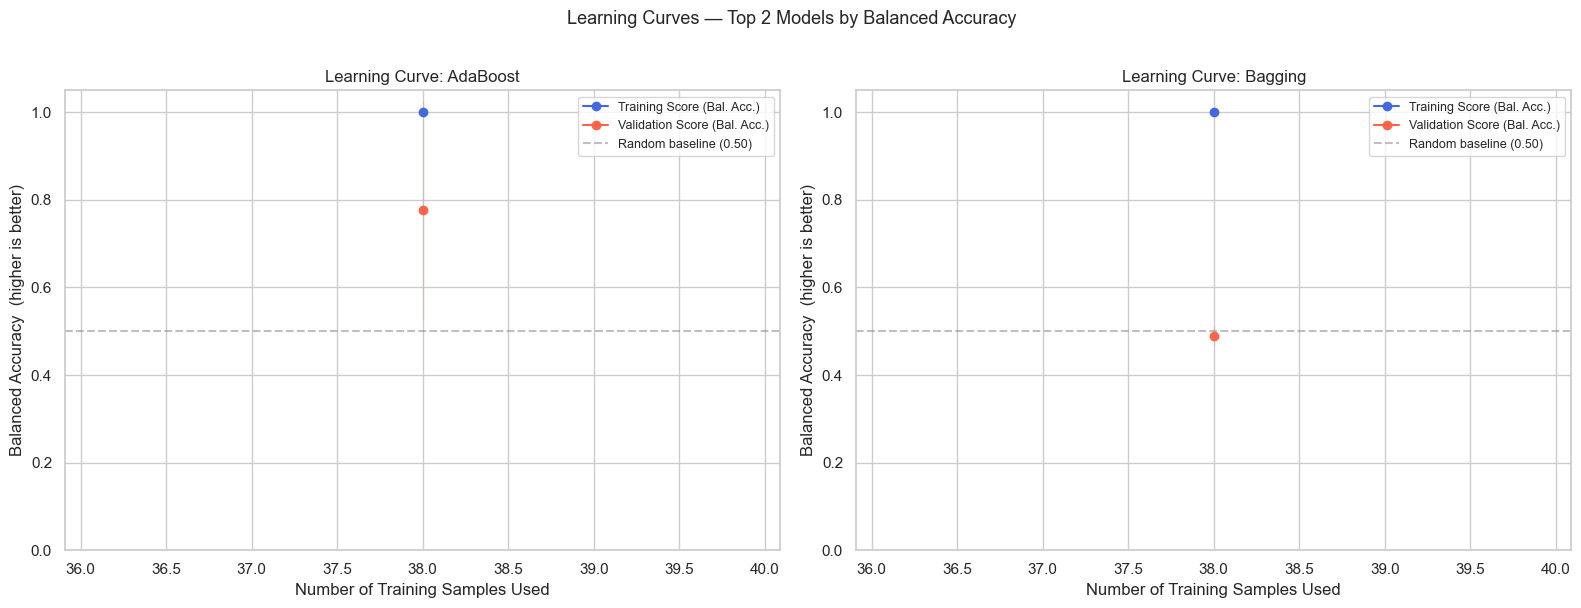

How to interpret these curves:
  - If the validation line is still rising at the right edge → the model needs MORE DATA
  - If there's a large gap between train and val → the model is OVERFITTING
  - With only 60 residents, variability (shaded bands) will be high — this is expected.
  - The baseline is now 0.50 (binary random chance), not 0.25.


In [30]:
# =============================================================================
# PHASE 5, STEP 2: Learning Curves
#
# A learning curve trains the model on progressively larger portions of the
# training data and records performance at each size.
#
# HOW TO READ:
#   Blue line  = Training score (how well the model fits its own training data)
#   Red line   = Validation score (how well it performs on held-out folds)
#   Large gap  = Overfitting (model memorizes but doesn't generalize)
#   Both lines converging to a high score = Good generalization
#   Both lines low = Underfitting (model is too simple to learn the patterns)
#
# With only 60 residents, we expect high variability and some signs of
# data hunger — the model may improve substantially when more data is available.
# =============================================================================

# Select the top 2 models by balanced accuracy for learning curve analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, top_two_names):
    # Train the model on 10 different sizes (20% to 100% of training data)
    # Use only 5 evenly spaced points to avoid crashing with very small subsets
    train_sizes = np.linspace(0.2, 1.0, 8)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        models[name],
        X_train, y_train,
        cv=skf,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes_abs, train_mean, "o-", color="royalblue", label="Training Score (Bal. Acc.)")
    ax.plot(train_sizes_abs, val_mean,   "o-", color="tomato",    label="Validation Score (Bal. Acc.)")
    ax.fill_between(train_sizes_abs,
                    train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color="royalblue")
    ax.fill_between(train_sizes_abs,
                    val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color="tomato")
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline (0.50)")
    ax.set_title(f"Learning Curve: {name}", fontsize=12)
    ax.set_xlabel("Number of Training Samples Used")
    ax.set_ylabel("Balanced Accuracy  (higher is better)")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

plt.suptitle("Learning Curves — Top 2 Models by Balanced Accuracy", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("How to interpret these curves:")
print("  - If the validation line is still rising at the right edge → the model needs MORE DATA")
print("  - If there's a large gap between train and val → the model is OVERFITTING")
print("  - With only 60 residents, variability (shaded bands) will be high — this is expected.")
print("  - The baseline is now 0.50 (binary random chance), not 0.25.")

Best model by Balanced Accuracy: AdaBoost  (Bal. Acc. = 0.776)
Generating validation curve for 'n_estimators' (number of trees)...



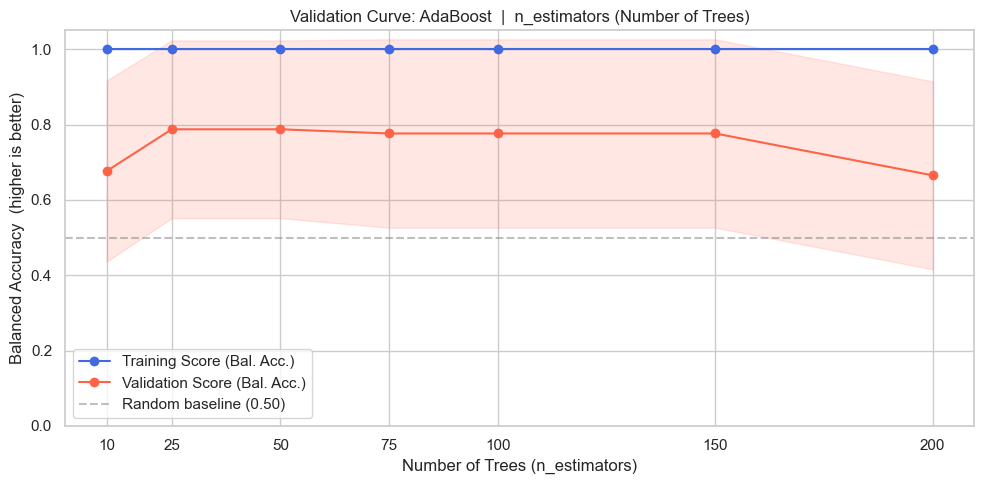

Optimal n_estimators based on validation Balanced Accuracy: 25
Beyond this value, adding more trees yields diminishing returns.


In [31]:
# =============================================================================
# PHASE 5, STEP 3: Validation Curve for the Best Model
#
# A validation curve shows how performance changes as we vary ONE hyperparameter.
# We vary n_estimators (number of trees) for the best model.
#
# HOW TO READ:
#   Blue line  = Training score (how the model performs on its own data)
#   Red line   = Validation score (how it performs on held-out data)
#   The "sweet spot" is where the validation line peaks — more trees beyond
#   that point yields diminishing returns.
# =============================================================================

print(f"Best model by Balanced Accuracy: {best_model_name}  (Bal. Acc. = {best_model_bacc:.3f})")
print(f"Generating validation curve for 'n_estimators' (number of trees)...\n")

param_range = [10, 25, 50, 75, 100, 150, 200]

train_scores_vc, val_scores_vc = validation_curve(
    models[best_model_name],
    X_train, y_train,
    param_name="model__n_estimators",
    param_range=param_range,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

train_mean_vc = train_scores_vc.mean(axis=1)
val_mean_vc   = val_scores_vc.mean(axis=1)
train_std_vc  = train_scores_vc.std(axis=1)
val_std_vc    = val_scores_vc.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mean_vc, "o-", color="royalblue", label="Training Score (Bal. Acc.)")
plt.plot(param_range, val_mean_vc,   "o-", color="tomato",    label="Validation Score (Bal. Acc.)")
plt.fill_between(param_range,
                 train_mean_vc - train_std_vc, train_mean_vc + train_std_vc,
                 alpha=0.15, color="royalblue")
plt.fill_between(param_range,
                 val_mean_vc - val_std_vc, val_mean_vc + val_std_vc,
                 alpha=0.15, color="tomato")
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline (0.50)")
plt.title(f"Validation Curve: {best_model_name}  |  n_estimators (Number of Trees)", fontsize=12)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Balanced Accuracy  (higher is better)")
plt.xticks(param_range)
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

optimal_n = param_range[int(np.argmax(val_mean_vc))]
print(f"Optimal n_estimators based on validation Balanced Accuracy: {optimal_n}")
print("Beyond this value, adding more trees yields diminishing returns.")

In [32]:
# =============================================================================
# PHASE 5, STEP 4: GridSearchCV on Random Forest
#
# GridSearchCV tries EVERY combination of hyperparameter values we provide.
# Think of it like trying every key on a keychain one by one — exhaustive but thorough.
# Each combination is evaluated with cross-validation for a fair comparison.
#
# Parameters we are tuning:
#   n_estimators     — how many decision trees to build
#   max_depth        — how deep each tree can grow (None = no limit)
#   min_samples_leaf — minimum data points required at each leaf of the tree
# =============================================================================

import time
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "model__n_estimators":     [50, 100, 200],
    "model__max_depth":        [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
}

n_combinations = 1
for v in rf_param_grid.values():
    n_combinations *= len(v)
print(f"Running GridSearchCV on Random Forest...")
print(f"Total model fits: {n_combinations * skf.n_splits}  ({n_combinations} combinations × {skf.n_splits} folds)")
print("This may take a few minutes on a small machine.\n")

rf_grid_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
rf_grid = GridSearchCV(
    rf_grid_pipeline,
    rf_param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    refit=True,
)
rf_grid.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Complete in {elapsed:.1f} seconds.\n")
print("Best hyperparameters (Random Forest):")
for param, value in rf_grid.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {value}")
print()
print(f"Best CV Balanced Accuracy: {rf_grid.best_score_:.4f}")
tuned_rf = rf_grid.best_estimator_

Running GridSearchCV on Random Forest...
Total model fits: 135  (27 combinations × 5 folds)
This may take a few minutes on a small machine.

Complete in 3.5 seconds.

Best hyperparameters (Random Forest):
  max_depth                 None
  min_samples_leaf          1
  n_estimators              50

Best CV Balanced Accuracy: 0.5875


In [33]:
# =============================================================================
# PHASE 5, STEP 5: RandomizedSearchCV on Gradient Boosting
#
# Instead of trying EVERY combination (like GridSearchCV), RandomizedSearchCV
# randomly samples from the parameter space. This is faster and often finds
# nearly as good a result in a fraction of the time.
#
# Parameters we are tuning:
#   n_estimators   — number of boosting rounds (trees)
#   max_depth      — how deep each tree can grow
#   learning_rate  — how much each tree contributes (smaller = more conservative,
#                    requires more trees to compensate)
#   subsample      — fraction of training data used per tree (adds randomness)
# =============================================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

gb_param_dist = {
    "model__n_estimators": randint(50, 300),
    "model__max_depth":    randint(2, 8),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample":    uniform(0.6, 0.4),
}

print("Running RandomizedSearchCV on Gradient Boosting...")
print(f"Sampling 20 random hyperparameter combinations × {skf.n_splits} folds = {20 * skf.n_splits} model fits")
print("This is ~3× fewer fits than full GridSearch, but often finds comparably good results.\n")

gb_random_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
            k_neighbors=2,           # Small dataset: CV folds may have as few as 4 minority samples; k+1 must be <= that count
            random_state=RANDOM_STATE,
        )),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

t0 = time.time()
gb_random = RandomizedSearchCV(
    gb_random_pipeline,
    gb_param_dist,
    n_iter=20,
    cv=skf,
    scoring="balanced_accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
gb_random.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Complete in {elapsed:.1f} seconds.\n")
print("Best hyperparameters (Gradient Boosting):")
for param, value in gb_random.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {value:.4f}" if isinstance(value, float) else
          f"  {param.replace('model__', ''):<25} {value}")
print()
print(f"Best CV Balanced Accuracy: {gb_random.best_score_:.4f}")
tuned_gb = gb_random.best_estimator_

Running RandomizedSearchCV on Gradient Boosting...
Sampling 20 random hyperparameter combinations × 5 folds = 100 model fits
This is ~3× fewer fits than full GridSearch, but often finds comparably good results.

Complete in 1.1 seconds.

Best hyperparameters (Gradient Boosting):
  learning_rate             0.0717
  max_depth                 6
  n_estimators              112
  subsample                 0.6680

Best CV Balanced Accuracy: 0.6875


In [34]:
# =============================================================================
# PHASE 5, STEP 6: Updated comparison table including tuned models
#
# We add the two tuned models to the comparison table so we can see
# whether hyperparameter tuning improved performance.
# =============================================================================

# Re-cross-validate the two tuned models
tuned_models = {
    "Random Forest (Tuned)":    tuned_rf,
    "Gradient Boosting (Tuned)": tuned_gb,
}

print("Re-cross-validating tuned models...")
for name, pipeline in tuned_models.items():
    print(f"  Evaluating: {name}...", end=" ", flush=True)
    results = cross_validate(
        pipeline,
        X_train, y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_results[name] = results

    acc  = np.mean(results["test_accuracy"])
    bal  = np.mean(results["test_balanced_accuracy"])
    f1w  = np.mean(results["test_f1_weighted"])
    f1m  = np.mean(results["test_f1_macro"])
    print(f"Done  |  Acc={acc:.3f}  BalAcc={bal:.3f}  F1-W={f1w:.3f}  F1-M={f1m:.3f}")

print()

# --- Full updated comparison table ---
print("=" * 90)
print("UPDATED MODEL COMPARISON TABLE — All 7 Models (5 base + 2 tuned, all with SMOTE)")
print("Sorted by Balanced Accuracy (primary metric). Tuned models marked with *")
print("=" * 90)
print()
print(f"{'Model':<28}  {'Accuracy':>12}  {'Bal. Acc.':>12}  {'F1 (Wtd)':>12}  {'F1 (Macro)':>12}")
print("-" * 84)

all_rows = []
for name, results in cv_results.items():
    acc  = np.mean(results["test_accuracy"])
    bacc = np.mean(results["test_balanced_accuracy"])
    f1w  = np.mean(results["test_f1_weighted"])
    f1m  = np.mean(results["test_f1_macro"])
    acc_std  = np.std(results["test_accuracy"])
    bacc_std = np.std(results["test_balanced_accuracy"])
    f1w_std  = np.std(results["test_f1_weighted"])
    f1m_std  = np.std(results["test_f1_macro"])
    all_rows.append({
        "Model": name, "Accuracy": acc, "Balanced Acc.": bacc,
        "F1 (Weighted)": f1w, "F1 (Macro)": f1m,
    })
    print(f"{name:<28}  {acc:.3f} ± {acc_std:.3f}  {bacc:.3f} ± {bacc_std:.3f}  {f1w:.3f} ± {f1w_std:.3f}  {f1m:.3f} ± {f1m_std:.3f}")

all_df = pd.DataFrame(all_rows).sort_values("Balanced Acc.", ascending=False)
best_overall_name = all_df.iloc[0]["Model"]
best_overall_bacc = all_df.iloc[0]["Balanced Acc."]

# Get the best pipeline object
all_pipelines = {**models, **tuned_models}
best_overall_pipeline = all_pipelines[best_overall_name]

print()
print(f"Best overall model: {best_overall_name}")
print(f"Best CV Balanced Accuracy: {best_overall_bacc:.4f}")

Re-cross-validating tuned models...
  Evaluating: Random Forest (Tuned)... Done  |  Acc=0.896  BalAcc=0.588  F1-W=0.860  F1-M=0.538
  Evaluating: Gradient Boosting (Tuned)... Done  |  Acc=0.916  BalAcc=0.688  F1-W=0.889  F1-M=0.644

UPDATED MODEL COMPARISON TABLE — All 7 Models (5 base + 2 tuned, all with SMOTE)
Sorted by Balanced Accuracy (primary metric). Tuned models marked with *

Model                             Accuracy     Bal. Acc.      F1 (Wtd)    F1 (Macro)
------------------------------------------------------------------------------------
Random Forest                 0.873 ± 0.048  0.487 ± 0.025  0.834 ± 0.029  0.466 ± 0.014
Gradient Boosting             0.876 ± 0.038  0.576 ± 0.182  0.849 ± 0.033  0.532 ± 0.134
Extra Trees                   0.873 ± 0.048  0.487 ± 0.025  0.834 ± 0.029  0.466 ± 0.014
AdaBoost                      0.918 ± 0.076  0.776 ± 0.250  0.911 ± 0.080  0.744 ± 0.244
Bagging                       0.876 ± 0.038  0.576 ± 0.182  0.849 ± 0.033  0.532 ± 0.1

Fitting best model (AdaBoost) on full training set...

FINAL TEST SET EVALUATION (UNSEEN DATA) — Binary Classification

  Accuracy             : 0.8333  (83.3% correct)
  Balanced Accuracy    : 0.4545  (primary metric — treats both classes equally)

Classification Report (per risk class):

               precision    recall  f1-score   support

Standard Risk       0.91      0.91      0.91        11
Elevated Risk       0.00      0.00      0.00         1

     accuracy                           0.83        12
    macro avg       0.45      0.45      0.45        12
 weighted avg       0.83      0.83      0.83        12



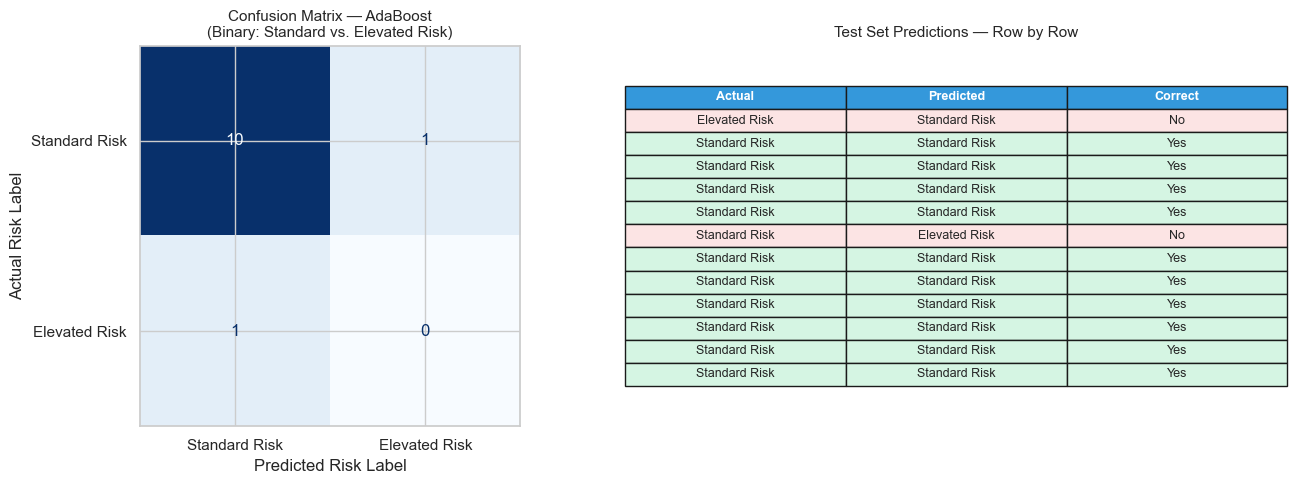


Summary: The model correctly classified 10 of 12 test residents.
Elevated Risk recall: 0/1 Elevated residents correctly flagged.


In [35]:
# =============================================================================
# PHASE 5, STEP 7: Final Test Evaluation
#
# This is the ONE honest look at performance on completely unseen data.
# The test set has been frozen since Phase 3 — the model has never seen it.
# This score represents how well the model would perform in the real world.
#
# We evaluate:
#   - Confusion matrix: shows exactly how Standard vs. Elevated are classified
#   - Classification report: per-class precision, recall, and F1
#   - Safety rule flags: which residents trigger hard clinical rules
#   - Combined table: model prediction + rule flags side by side
# =============================================================================

from sklearn.metrics import (
    confusion_matrix, classification_report, balanced_accuracy_score,
    accuracy_score, ConfusionMatrixDisplay
)

# Fit the best overall pipeline on the FULL training set and predict on test set
print(f"Fitting best model ({best_overall_name}) on full training set...")
best_overall_pipeline.fit(X_train, y_train)
y_pred = best_overall_pipeline.predict(X_test)

# Convert predictions back to label strings for display
y_pred_labels      = pd.Series(y_pred).map(ORDINAL_MAP_INVERSE).values
y_test_labels_arr  = y_test.map(ORDINAL_MAP_INVERSE).values
binary_labels_disp = ["Standard Risk", "Elevated Risk"]

# --- Performance metrics ---
test_acc  = accuracy_score(y_test, y_pred)
test_bacc = balanced_accuracy_score(y_test, y_pred)

print()
print("=" * 65)
print("FINAL TEST SET EVALUATION (UNSEEN DATA) — Binary Classification")
print("=" * 65)
print()
print(f"  Accuracy             : {test_acc:.4f}  ({test_acc*100:.1f}% correct)")
print(f"  Balanced Accuracy    : {test_bacc:.4f}  (primary metric — treats both classes equally)")
print()

# --- Classification Report ---
print("Classification Report (per risk class):")
print()
print(classification_report(
    y_test_labels_arr, y_pred_labels,
    labels=binary_labels_disp,
    zero_division=0,
))

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_labels_arr, y_pred_labels, labels=binary_labels_disp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=binary_labels_disp)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_overall_name}\n(Binary: Standard vs. Elevated Risk)",
                  fontsize=11)
axes[0].set_xlabel("Predicted Risk Label")
axes[0].set_ylabel("Actual Risk Label")

# --- Row-by-row prediction detail table ---
pred_detail = pd.DataFrame({
    "Actual":    y_test_labels_arr,
    "Predicted": y_pred_labels,
    "Correct":   ["Yes" if a == p else "No" for a, p in zip(y_test_labels_arr, y_pred_labels)],
}).reset_index(drop=True)

axes[1].axis("off")
tbl_data = pred_detail.values.tolist()
tbl_cols = pred_detail.columns.tolist()
tbl = axes[1].table(
    cellText=tbl_data,
    colLabels=tbl_cols,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#3498db")
        cell.set_text_props(color="white", fontweight="bold")
    elif row > 0 and tbl_data[row-1][2] == "Yes":
        cell.set_facecolor("#d5f5e3")
    else:
        cell.set_facecolor("#fce4e4")
axes[1].set_title("Test Set Predictions — Row by Row", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nSummary: The model correctly classified {sum(y_pred == y_test.values)} of {len(y_test)} test residents.")
n_elevated_test = sum(y_test.values == 1)
n_elevated_caught = sum((y_pred == 1) & (y_test.values == 1))
if n_elevated_test > 0:
    print(f"Elevated Risk recall: {n_elevated_caught}/{n_elevated_test} Elevated residents correctly flagged.")

SAFETY RULE LAYER - Test Set Results

           Actual     Model Pred Rule Flag Combined Alert SelfHarm>0 HighSev>=50% Runaway>=2 SafetyConcern>=50% Unfavorable>=50%
0   Elevated Risk  Standard Risk         -       standard          .            .          .                  .                .
1   Standard Risk  Standard Risk         -       standard          .            .          .                  .                .
2   Standard Risk  Standard Risk         -       standard          .            .          .                  .                .
3   Standard Risk  Standard Risk         -       standard          .            .          .                  .                .
4   Standard Risk  Standard Risk         -       standard          .            .          .                  .                .
5   Standard Risk  Elevated Risk         -       ELEVATED          .            .          .                  .                .
6   Standard Risk  Standard Risk         -       standard  

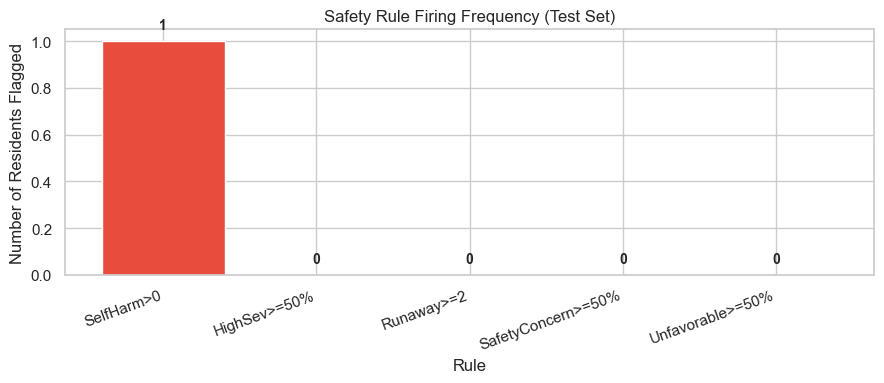

In [36]:
# =============================================================================
# PHASE 5, STEP 8: Rule-Based Safety Layer
#
# The ML model gives probabilistic predictions. But some clinical signals are
# serious enough that we want to flag them regardless of model output:
#
#   Rule 1 - Any self-harm event on record
#   Rule 2 - 50%+ of incidents are High severity
#   Rule 3 - 2 or more runaway attempts
#   Rule 4 - 50%+ of home visits noted safety concerns
#   Rule 5 - 50%+ of home visits had Unfavorable outcomes
#
# This section applies these rules to the TEST SET and shows a combined
# table: Model Prediction + Individual Rule Flags + Final Combined Alert.
#
# COMBINED ALERT LOGIC:
#   If model predicts "Elevated Risk"  -> alert
#   If ANY rule fires                  -> alert
#   Both signals are shown so staff can see which one triggered.
# =============================================================================

import operator as _op

_ops = {">": _op.gt, ">=": _op.ge, "<": _op.lt, "<=": _op.le, "==": _op.eq}


def apply_safety_rules(X_features, rules_dict):
    # Returns a DataFrame with one boolean column per rule.
    # True means the rule fired (Elevated Risk flag).
    rule_flags = {}
    for rule_name, (col, op_str, threshold) in rules_dict.items():
        if col in X_features.columns:
            rule_flags[rule_name] = _ops[op_str](X_features[col], threshold).values
        else:
            rule_flags[rule_name] = [False] * len(X_features)
    return pd.DataFrame(rule_flags, index=range(len(X_features)))


# Apply rules to the test set (raw features — SMOTE is NOT applied to the test set)
# Reset index so the rule_flags DataFrame aligns with y_pred_labels (both start at 0)
X_test_reset = X_test.reset_index(drop=True)
rule_flags_test = apply_safety_rules(X_test_reset, SAFETY_RULES)
any_rule_fired  = rule_flags_test.any(axis=1).values   # numpy bool array, length = test set size

# Build combined results table (all columns as plain lists — avoids Series index mismatches)
rule_short = {
    "num_self_harm_gt_0":          "SelfHarm>0",
    "pct_high_severity_gte_50pct": "HighSev>=50%",
    "num_runaway_gte_2":           "Runaway>=2",
    "pct_safety_concerns_gte_50":  "SafetyConcern>=50%",
    "pct_unfavorable_gte_50":      "Unfavorable>=50%",
}

combined = pd.DataFrame({
    "Actual":         list(y_test_labels_arr),
    "Model Pred":     list(y_pred_labels),
    "Rule Flag":      ["FLAGGED" if f else "-" for f in any_rule_fired],
    "Combined Alert": [
        "ELEVATED" if (ml == "Elevated Risk" or rf) else "standard"
        for ml, rf in zip(y_pred_labels, any_rule_fired)
    ],
})

# Append individual rule columns (short names for table display)
for rule_name, short in rule_short.items():
    combined[short] = ["Y" if v else "." for v in rule_flags_test[rule_name]]

print("=" * 90)
print("SAFETY RULE LAYER - Test Set Results")
print("=" * 90)
print()
print(combined.to_string(index=True))
print()

# Summary statistics
n_test            = len(combined)
n_model_elevated  = (combined["Model Pred"] == "Elevated Risk").sum()
n_rule_flagged    = (combined["Rule Flag"] == "FLAGGED").sum()
n_combined_alert  = (combined["Combined Alert"] == "ELEVATED").sum()
n_actual_elevated = (combined["Actual"] == "Elevated Risk").sum()

print("Summary:")
print(f"  Test residents                     : {n_test}")
print(f"  Actual Elevated Risk               : {n_actual_elevated}")
print(f"  Model predicted Elevated Risk      : {n_model_elevated}")
print(f"  Rule layer flagged Elevated Risk   : {n_rule_flagged}")
print(f"  Combined alerts (model OR rules)   : {n_combined_alert}")
print()

# Recall improvement from adding the safety rule layer
actual_elevated_idx = (combined["Actual"] == "Elevated Risk")
if n_actual_elevated > 0:
    model_caught    = ((combined["Model Pred"] == "Elevated Risk") & actual_elevated_idx).sum()
    combined_caught = ((combined["Combined Alert"] == "ELEVATED") & actual_elevated_idx).sum()
    model_recall    = model_caught / n_actual_elevated * 100
    combined_recall = combined_caught / n_actual_elevated * 100
    print(f"  Model-alone Elevated recall      : {model_caught}/{n_actual_elevated}  ({model_recall:.0f}%)")
    print(f"  Combined (model+rules) recall    : {combined_caught}/{n_actual_elevated}  ({combined_recall:.0f}%)")

print()
print("Interpretation:")
print("  'Rule Flag = FLAGGED' means at least one clinical threshold was breached.")
print("  'Combined Alert = ELEVATED' means the model OR the rules flagged this resident.")
print("  Staff should review any resident where Combined Alert = ELEVATED.")

# --- Chart: Rule firing frequency ---
rule_fire_counts = pd.Series(
    {rule_short[k]: int(rule_flags_test[k].sum()) for k in rule_short}
)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#e74c3c" if v > 0 else "#95a5a6" for v in rule_fire_counts.values]
ax.bar(rule_fire_counts.index, rule_fire_counts.values, color=colors)
ax.set_title("Safety Rule Firing Frequency (Test Set)", fontsize=12)
ax.set_xlabel("Rule")
ax.set_ylabel("Number of Residents Flagged")
for i, val in enumerate(rule_fire_counts.values):
    ax.text(i, val + 0.05, str(int(val)), ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

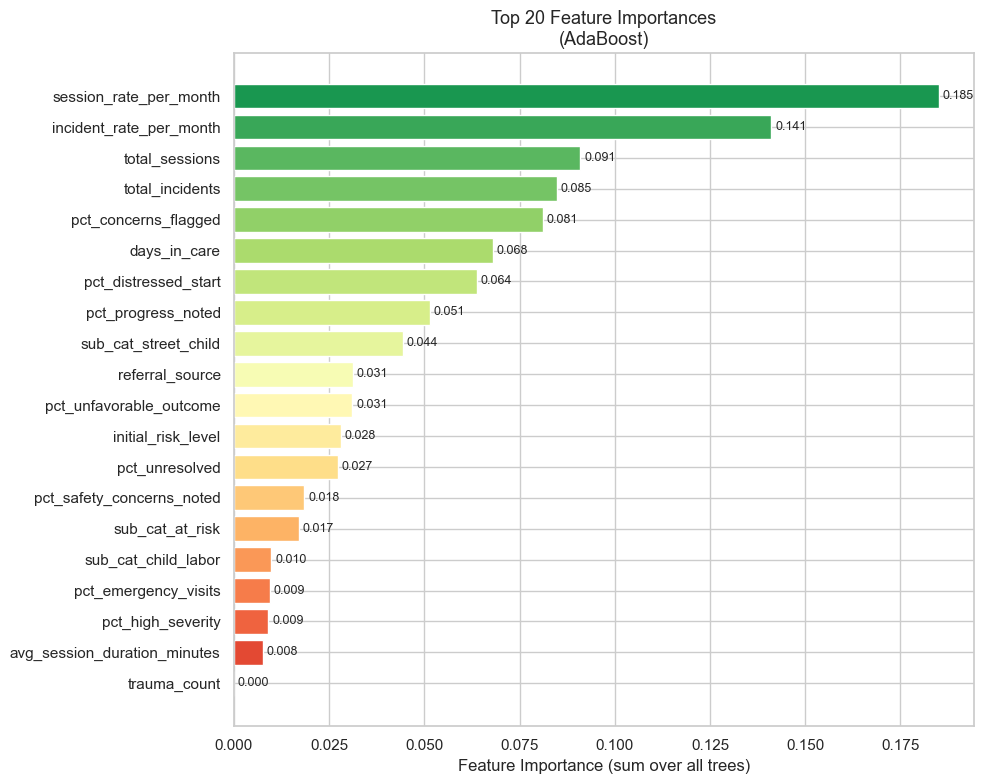

Top 5 most important features for predicting resident risk:
  1. session_rate_per_month                   importance = 0.1851
  2. incident_rate_per_month                  importance = 0.1411
  3. total_sessions                           importance = 0.0909
  4. total_incidents                          importance = 0.0849
  5. pct_concerns_flagged                     importance = 0.0811


In [37]:
# =============================================================================
# PHASE 5, STEP 8: Feature Importance
#
# Which features are most important for predicting risk level?
# Tree-based ensemble models naturally track this — each time a feature is
# used to make a split in a tree, it gets credit for how much it reduced
# prediction error. The total credit across all trees is the feature's importance.
#
# This chart helps social workers understand WHAT the model is basing its
# predictions on — building trust and identifying the most critical data to collect.
# =============================================================================

# Extract feature importance from the best model
# We need to get the feature names after one-hot encoding
try:
    # Try to get the fitted model's feature importances
    fitted_model = best_overall_pipeline.named_steps["model"]

    if hasattr(fitted_model, "feature_importances_"):
        importances = fitted_model.feature_importances_

        # Get feature names from the preprocessor (after one-hot encoding expands categoricals)
        fitted_preprocessor = best_overall_pipeline.named_steps["preprocessor"]
        ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
        all_feature_names = numeric_cols + cat_feature_names

        # Summarize: for one-hot encoded features, sum importances back to the original column
        importance_dict = {}
        for name_f, imp in zip(all_feature_names, importances):
            # One-hot names look like "column_value" — extract the base column name
            base = name_f.split("_")[0] if any(name_f.startswith(c + "_") for c in categorical_cols) else name_f
            # More robust: check which original column the OHE feature came from
            for orig_col in categorical_cols:
                if name_f.startswith(orig_col + "_") or name_f == orig_col:
                    base = orig_col
                    break
            importance_dict[base] = importance_dict.get(base, 0) + imp

        importance_series = pd.Series(importance_dict).sort_values(ascending=False)
        top_n = min(20, len(importance_series))
        top_features = importance_series.head(top_n)

        # Chart
        fig, ax = plt.subplots(figsize=(10, 8))
        bars = ax.barh(
            range(top_n),
            top_features.values,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n)),
        )
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_features.index.tolist())
        ax.invert_yaxis()
        ax.set_title(f"Top {top_n} Feature Importances\n({best_overall_name})", fontsize=13)
        ax.set_xlabel("Feature Importance (sum over all trees)")
        for bar, val in zip(bars, top_features.values):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va="center", fontsize=9)
        plt.tight_layout()
        plt.show()

        print("Top 5 most important features for predicting resident risk:")
        for i, (feat, imp) in enumerate(top_features.head(5).items(), 1):
            print(f"  {i}. {feat:<40} importance = {imp:.4f}")
    else:
        print(f"Note: {best_overall_name} does not expose feature_importances_.")
        print("Feature importance chart is available for Random Forest, Gradient Boosting, and Extra Trees.")

except Exception as e:
    print(f"Feature importance extraction error: {e}")
    print("Skipping feature importance chart.")

# Phase 6: Deployment

In this final phase, we:

1. **Save the trained model** to disk so it can be loaded and used later without retraining
2. **Write a `predict_risk()` function** — a clean, reusable interface for making predictions
   on new resident data

### How the model will be used:
When a new resident is admitted, or when existing case data is updated, the organization
can call `predict_risk()` with the resident's data and receive a risk level prediction
along with a confidence breakdown across all four levels.

### Saved files:
- `models/resident_risk_model.joblib` — the full pipeline (preprocessor + model)
- `models/resident_risk_metadata.joblib` — feature list, performance metrics, column names

### Retraining:
As new data arrives, retraining is simple:
1. Update the CSV paths in the Config cell (Cell 1)
2. Run the notebook from top to bottom
3. The new best model is automatically saved to `models/`

In [38]:
# =============================================================================
# PHASE 6, STEP 1: Save the trained model and metadata to disk
# =============================================================================

import os
import joblib

# Create the models/ folder if it does not already exist
os.makedirs("models", exist_ok=True)

# --- Save the full pipeline (preprocessor + SMOTE + model) ---
# joblib.dump saves a Python object to a file, like packaging it for shipping.
# We save the ENTIRE pipeline so that when it is loaded later, all the
# preprocessing steps (scaling, encoding) come with it automatically.
# No re-running of any transformation code is needed at inference time.
# NOTE: SMOTE is part of the pipeline but is NOT applied during predict() —
# it only runs during fit(). The saved model predicts on raw input as expected.
joblib.dump(best_overall_pipeline, MODEL_SAVE_PATH)
print(f"Model saved: {MODEL_SAVE_PATH}")

# --- Save model metadata ---
# This stores key information about the model so that other code
# (like a website dashboard) knows exactly what columns to provide
# and what performance to expect.
model_metadata = {
    "model_name":           best_overall_name,
    "target_col":           TARGET_COL,
    "task_type":            "binary_classification",
    "binary_classes":       {0: "Standard Risk", 1: "Elevated Risk"},
    "class_merge_map":      {"Low": 0, "Medium": 0, "High": 1, "Critical": 1},
    "feature_cols":         feature_cols,
    "numeric_cols":         numeric_cols,
    "categorical_cols":     categorical_cols,
    "ordinal_map":          ORDINAL_MAP,
    "ordinal_map_inverse":  ORDINAL_MAP_INVERSE,
    "safety_rules":         SAFETY_RULES,
    "cv_balanced_acc":      float(best_overall_bacc),
    "test_accuracy":        float(test_acc),
    "test_balanced_acc":    float(test_bacc),
    "agg_cols_from_incidents":   list(inc_agg.columns[1:]),
    "agg_cols_from_process":     list(proc_agg.columns[1:]),
    "agg_cols_from_visitations": list(vis_agg.columns[1:]),
}

metadata_save_path = "models/resident_risk_metadata.joblib"
joblib.dump(model_metadata, metadata_save_path)
print(f"Metadata saved: {metadata_save_path}")

# --- Quick verification: load and predict to confirm nothing is broken ---
print()
print("Verifying saved model (predicting on 3 test samples)...")
loaded_model = joblib.load(MODEL_SAVE_PATH)
verify_preds  = loaded_model.predict(X_test.iloc[:3])
verify_labels = [ORDINAL_MAP_INVERSE[p] for p in verify_preds]
actual_labels = [ORDINAL_MAP_INVERSE[a] for a in y_test.values[:3]]

print(f"  Predicted: {verify_labels}")
print(f"  Actual:    {actual_labels}")
print()
print("Model saved and verified successfully.")

Model saved: models/resident_risk_model.joblib
Metadata saved: models/resident_risk_metadata.joblib

Verifying saved model (predicting on 3 test samples)...
  Predicted: ['Standard Risk', 'Standard Risk', 'Standard Risk']
  Actual:    ['Elevated Risk', 'Standard Risk', 'Standard Risk']

Model saved and verified successfully.


In [39]:
# =============================================================================
# PHASE 6, STEP 2: predict_risk() — Reusable Inference Function
#
# This function is the public-facing interface for the model.
# Give it a DataFrame containing resident data (from the residents table plus
# the three supporting tables), and it returns:
#   - predicted_risk_label  : "Standard Risk" or "Elevated Risk"
#   - confidence_standard   : model probability for Standard Risk (0–1)
#   - confidence_elevated   : model probability for Elevated Risk (0–1)
#   - rule_flag             : True if ANY safety rule fired
#   - rules_triggered       : comma-separated list of which rules fired
#   - combined_alert        : "Elevated Risk" if model OR any rule flagged
#
# GENERALIZATION: Works with any dataset that has the required columns.
# If columns are missing, it raises a clear, descriptive error.
# =============================================================================

import joblib
import operator as _op_module
import numpy as np
import pandas as pd
from datetime import datetime


def predict_risk(
    df_residents_new,
    df_incidents_new=None,
    df_process_new=None,
    df_visitations_new=None,
    model_path=MODEL_SAVE_PATH,
    metadata_path="models/resident_risk_metadata.joblib",
):
    """
    Predict binary risk level for one or more residents, with safety rule layer.

    Parameters
    ----------
    df_residents_new : pd.DataFrame
        DataFrame from the residents table. Must contain 'resident_id'.

    df_incidents_new : pd.DataFrame, optional
        DataFrame from incident_reports. If None, incident features default to 0.

    df_process_new : pd.DataFrame, optional
        DataFrame from process_recordings. If None, session features default to 0.

    df_visitations_new : pd.DataFrame, optional
        DataFrame from home_visitations. If None, visitation features default to 0.

    model_path : str
        Path to the saved joblib model pipeline.

    metadata_path : str
        Path to the saved model metadata.

    Returns
    -------
    pd.DataFrame
        One row per resident with columns:
        resident_id, predicted_risk_label, confidence_standard, confidence_elevated,
        rule_flag, rules_triggered, combined_alert
    """

    # --- Load the saved pipeline and metadata ---
    pipeline = joblib.load(model_path)
    metadata = joblib.load(metadata_path)
    required_cols  = metadata["feature_cols"]
    ordinal_inv    = metadata["ordinal_map_inverse"]
    safety_rules   = metadata.get("safety_rules", {})

    # --- Step 1: Derive date-based features ---
    df_new = df_residents_new.copy()

    dob_dt   = pd.to_datetime(df_new.get("date_of_birth",     pd.NaT), errors="coerce")
    adm_dt   = pd.to_datetime(df_new.get("date_of_admission", pd.NaT), errors="coerce")
    ref_date = pd.Timestamp("today")

    df_new["age_at_admission"] = ((adm_dt - dob_dt).dt.days / 365.25).round(1)
    df_new["days_in_care"]     = (ref_date - adm_dt).dt.days.clip(lower=0)
    df_new["months_in_care"]   = (df_new["days_in_care"] / 30.44).clip(lower=1)

    sub_cat_cols_all = [c for c in df_new.columns if c.startswith("sub_cat_")]
    df_new["trauma_count"] = df_new[sub_cat_cols_all].sum(axis=1) if sub_cat_cols_all else 0

    # --- Step 2: Aggregate supporting tables (if provided) ---
    positive_emo = {"Hopeful", "Happy", "Calm"}
    negative_emo = {"Distressed", "Angry", "Anxious", "Sad", "Withdrawn"}

    # Incidents
    if df_incidents_new is not None and len(df_incidents_new) > 0:
        inc = df_incidents_new.copy()
        inc_a = inc.groupby("resident_id").agg(
            total_incidents        = ("incident_id",      "count"),
            num_self_harm          = ("incident_type",    lambda x: (x == "SelfHarm").sum()),
            num_runaway_attempts   = ("incident_type",    lambda x: (x == "RunawayAttempt").sum()),
            num_behavioral         = ("incident_type",    lambda x: (x == "Behavioral").sum()),
            pct_high_severity      = ("severity",         lambda x: (x == "High").mean()),
            pct_unresolved         = ("resolved",         lambda x: (~x).mean()),
            pct_follow_up_required = ("follow_up_required","mean"),
        ).reset_index()
        months_m = df_new.set_index("resident_id")["months_in_care"]
        inc_a["incident_rate_per_month"] = (
            inc_a["total_incidents"] / inc_a["resident_id"].map(months_m).clip(lower=1)
        )
        df_new = df_new.merge(inc_a, on="resident_id", how="left")
    for c in metadata["agg_cols_from_incidents"]:
        if c not in df_new.columns:
            df_new[c] = 0
    df_new[metadata["agg_cols_from_incidents"]] = df_new[metadata["agg_cols_from_incidents"]].fillna(0)

    # Process recordings
    if df_process_new is not None and len(df_process_new) > 0:
        proc = df_process_new.copy()
        proc["start_is_negative"] = proc["emotional_state_observed"].isin(negative_emo)
        proc["end_is_positive"]   = proc["emotional_state_end"].isin(positive_emo)
        proc["emotional_improved"] = proc["start_is_negative"] & proc["end_is_positive"]
        proc_a = proc.groupby("resident_id").agg(
            total_sessions               = ("recording_id",     "count"),
            pct_progress_noted           = ("progress_noted",   "mean"),
            pct_concerns_flagged         = ("concerns_flagged", "mean"),
            pct_referral_made            = ("referral_made",    "mean"),
            pct_distressed_start         = ("start_is_negative","mean"),
            pct_emotional_improvement    = ("emotional_improved","mean"),
            avg_session_duration_minutes = ("session_duration_minutes","mean"),
        ).reset_index()
        months_m = df_new.set_index("resident_id")["months_in_care"]
        proc_a["session_rate_per_month"] = (
            proc_a["total_sessions"] / proc_a["resident_id"].map(months_m).clip(lower=1)
        )
        df_new = df_new.merge(proc_a, on="resident_id", how="left")
    for c in metadata["agg_cols_from_process"]:
        if c not in df_new.columns:
            df_new[c] = 0
    df_new[metadata["agg_cols_from_process"]] = df_new[metadata["agg_cols_from_process"]].fillna(0)

    # Home visitations
    if df_visitations_new is not None and len(df_visitations_new) > 0:
        vis = df_visitations_new.copy()
        vis["is_uncooperative"] = vis["family_cooperation_level"] == "Uncooperative"
        vis["is_emergency"]     = vis["visit_type"] == "Emergency"
        vis["is_unfavorable"]   = vis["visit_outcome"] == "Unfavorable"
        vis_a = vis.groupby("resident_id").agg(
            total_visits              = ("visitation_id",       "count"),
            pct_safety_concerns_noted = ("safety_concerns_noted","mean"),
            pct_unfavorable_outcome   = ("is_unfavorable",       "mean"),
            pct_uncooperative_family  = ("is_uncooperative",     "mean"),
            pct_emergency_visits      = ("is_emergency",         "mean"),
            pct_follow_up_needed      = ("follow_up_needed",     "mean"),
        ).reset_index()
        df_new = df_new.merge(vis_a, on="resident_id", how="left")
    for c in metadata["agg_cols_from_visitations"]:
        if c not in df_new.columns:
            df_new[c] = 0
    df_new[metadata["agg_cols_from_visitations"]] = df_new[metadata["agg_cols_from_visitations"]].fillna(0)

    df_new = df_new.drop(
        columns=["months_in_care", "date_of_birth", "date_of_admission",
                 "date_enrolled", "date_closed", "created_at"],
        errors="ignore",
    )
    for col in df_new.select_dtypes(include=["bool"]).columns:
        df_new[col] = df_new[col].astype(int)

    # --- Step 3: Validate required columns ---
    missing_cols = [c for c in required_cols if c not in df_new.columns]
    if missing_cols:
        raise ValueError(
            f"The following required feature columns are missing from the input:\n"
            f"  {missing_cols}\n\n"
            f"All required columns: {required_cols}"
        )

    X_new = df_new[required_cols].copy()

    # --- Step 4: ML model prediction ---
    y_pred_scores = pipeline.predict(X_new)
    y_pred_labels_list = [ordinal_inv[s] for s in y_pred_scores]

    result = pd.DataFrame({
        "resident_id":         (
            df_new["resident_id"].values
            if "resident_id" in df_new.columns else range(len(df_new))
        ),
        "predicted_risk_label": y_pred_labels_list,
    })

    if hasattr(pipeline, "predict_proba"):
        proba   = pipeline.predict_proba(X_new)
        classes = pipeline.classes_
        for i, cls_idx in enumerate(classes):
            col_name = f"confidence_{ordinal_inv[cls_idx].lower().replace(' ', '_')}"
            result[col_name] = proba[:, i].round(3)

    # --- Step 5: Apply safety rules ---
    _ops_map = {">": _op_module.gt, ">=": _op_module.ge,
                "<": _op_module.lt, "<=": _op_module.le, "==": _op_module.eq}

    rule_flag_col      = []
    rules_triggered_col = []

    for idx in range(len(X_new)):
        fired = []
        for rule_name, (col, op_str, threshold) in safety_rules.items():
            if col in X_new.columns:
                val = X_new.iloc[idx][col]
                if _ops_map[op_str](val, threshold):
                    fired.append(rule_name)
        rule_flag_col.append(len(fired) > 0)
        rules_triggered_col.append(", ".join(fired) if fired else "none")

    result["rule_flag"]        = rule_flag_col
    result["rules_triggered"]  = rules_triggered_col

    # Combined alert: model says Elevated OR any rule fired
    result["combined_alert"] = [
        "Elevated Risk" if (ml == "Elevated Risk" or rf) else "Standard Risk"
        for ml, rf in zip(result["predicted_risk_label"], result["rule_flag"])
    ]

    return result


# =============================================================================
# DEMO: Run predict_risk() on a random sample of residents
# =============================================================================

print("=== DEMO: predict_risk() (Binary + Safety Rules) ===\n")

demo_residents   = pd.read_csv(RESIDENTS_PATH)
demo_incidents   = pd.read_csv(INCIDENTS_PATH)
demo_process     = pd.read_csv(PROCESS_PATH)
demo_visitations = pd.read_csv(VISITATIONS_PATH)

demo_sample = demo_residents.sample(8, random_state=42)

demo_result = predict_risk(
    df_residents_new   = demo_sample,
    df_incidents_new   = demo_incidents[demo_incidents["resident_id"].isin(demo_sample["resident_id"])],
    df_process_new     = demo_process[demo_process["resident_id"].isin(demo_sample["resident_id"])],
    df_visitations_new = demo_visitations[demo_visitations["resident_id"].isin(demo_sample["resident_id"])],
)

# Attach actual labels for comparison (binary mapping)
demo_sample_labels = demo_sample[["resident_id", "current_risk_level"]].copy()
# Map original 4-class labels to binary labels for comparison
_binary_label_map = {k: ORDINAL_MAP_INVERSE[v] for k, v in ORDINAL_MAP.items()}
demo_sample_labels["actual_binary"] = demo_sample_labels["current_risk_level"].map(_binary_label_map)
demo_result = demo_result.merge(
    demo_sample_labels[["resident_id", "current_risk_level", "actual_binary"]],
    on="resident_id", how="left"
)

display_cols = [
    "resident_id", "current_risk_level", "actual_binary",
    "predicted_risk_label", "rule_flag", "combined_alert", "rules_triggered",
]
print(demo_result[display_cols].to_string(index=False))
print()
n_correct = (demo_result["predicted_risk_label"] == demo_result["actual_binary"]).sum()
print(f"ML model correct predictions in demo: {n_correct} / {len(demo_result)}")
n_combined_correct = (demo_result["combined_alert"] == demo_result["actual_binary"]).sum()
print(f"Combined alert correct: {n_combined_correct} / {len(demo_result)}")
print()
print("predict_risk() is ready for integration into the Lighthouse Sanctuary dashboard.")
print()
print("Saved files:")
print(f"  {MODEL_SAVE_PATH}              — the trained pipeline")
print(f"  models/resident_risk_metadata.joblib  — feature list, class info, safety rules")
print()
print("To retrain on new data: update the CSV paths in the Config cell and re-run the notebook.")

=== DEMO: predict_risk() (Binary + Safety Rules) ===

 resident_id current_risk_level actual_binary predicted_risk_label  rule_flag combined_alert                                rules_triggered
           1               High Elevated Risk        Elevated Risk      False  Elevated Risk                                           none
           6             Medium Standard Risk        Standard Risk      False  Standard Risk                                           none
          37                Low Standard Risk        Standard Risk       True  Elevated Risk                             num_self_harm_gt_0
          46                Low Standard Risk        Standard Risk       True  Elevated Risk                             num_self_harm_gt_0
          14                Low Standard Risk        Standard Risk       True  Elevated Risk pct_high_severity_gte_50pct, num_runaway_gte_2
          55             Medium Standard Risk        Standard Risk      False  Standard Risk              